<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/objetvo_1_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Configuración de estilo
import matplotlib.pyplot as plt

# Print available styles to see if a valid seaborn style exists
print(plt.style.available)
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: '%.3f' % x)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [3]:
# Cargar datos
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'])

In [5]:
df.head()

,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Return_1d,AMZN_Return_1d,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE
0,2021-01-04,85.896,159.331,0.917,26.970,3700.650,12698.450,0.008,0.010,3.411,3.842,1.980
1,2021-01-05,86.589,160.926,0.955,25.340,3726.860,12818.960,0.008,0.010,3.411,3.842,2.010
2,2021-01-06,85.734,156.919,1.042,25.070,3748.140,12740.790,-0.010,-0.025,3.411,3.842,2.040
3,2021-01-07,88.295,158.108,1.071,22.370,3803.790,13067.480,0.030,0.008,3.411,3.842,2.090
4,2021-01-08,89.464,159.135,1.105,21.560,3824.680,13201.980,0.013,0.006,3.411,3.842,2.070


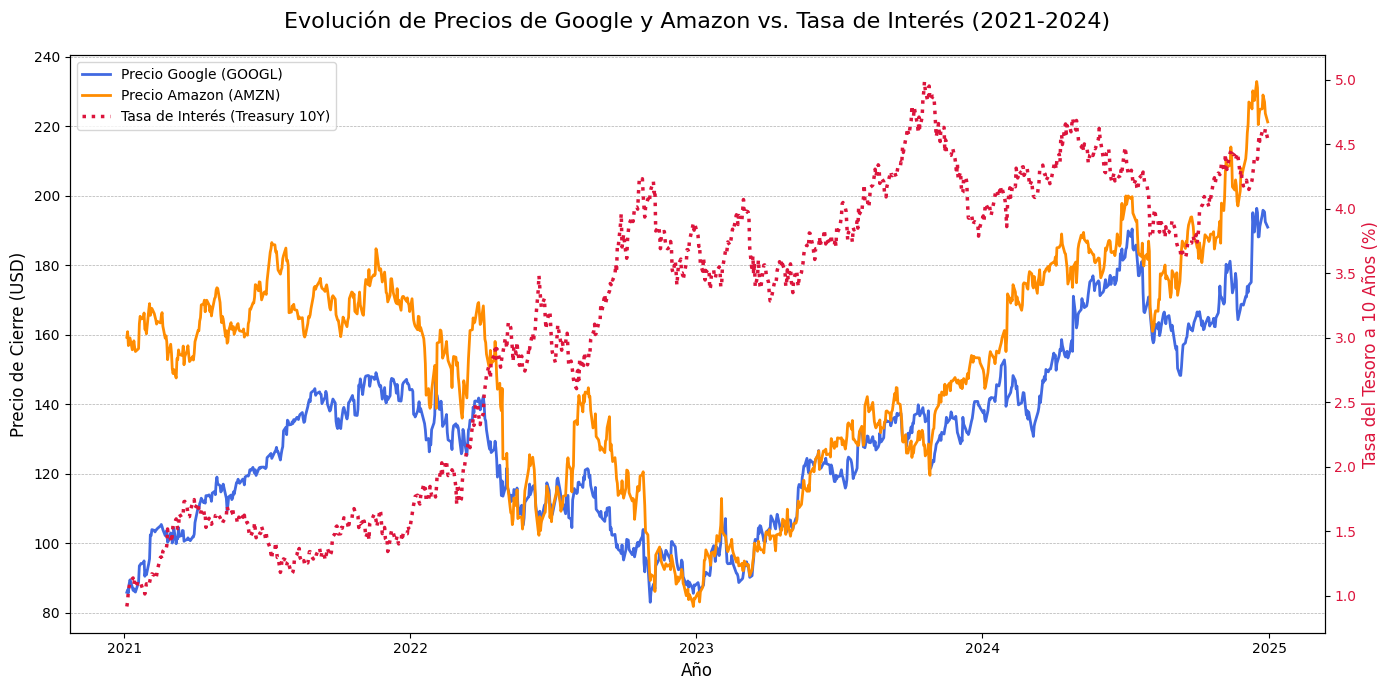

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. Carga de Datos ---
# Asegúrate de que la ruta al archivo sea correcta.
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- 2. Creación del Gráfico Comparativo ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Configuración del primer eje Y (Precios)
color_googl = 'royalblue'
color_amzn = 'darkorange'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Precio de Cierre (USD)', color='black', fontsize=12)
ax1.plot(df.index, df['GOOGL_Close'], color=color_googl, label='Precio Google (GOOGL)', linewidth=2)
ax1.plot(df.index, df['AMZN_Close'], color=color_amzn, label='Precio Amazon (AMZN)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='major', linestyle='--', linewidth=0.5, axis='y') # Rejilla solo para el eje de precios

# Configuración del segundo eje Y (Tasa de Interés)
ax2 = ax1.twinx()  # Crea un segundo eje que comparte el mismo eje X
color_tasa = 'crimson'
ax2.set_ylabel('Tasa del Tesoro a 10 Años (%)', color=color_tasa, fontsize=12)
ax2.plot(df.index, df['Treasury_10Y'], color=color_tasa, label='Tasa de Interés (Treasury 10Y)', linestyle=':', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color_tasa)

# --- Títulos y Leyendas ---
plt.title('Evolución de Precios de Google y Amazon vs. Tasa de Interés (2021-2024)', fontsize=16, pad=20)

# Combinar las leyendas de ambos ejes en una sola caja para mayor claridad
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# --- Formato del Eje X ---
# Asegurar que se muestren los años de forma clara
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0, ha='center')

# Ajuste final para evitar que las etiquetas se superpongan
fig.tight_layout()
plt.show()

--- Entrenando modelos SIN tasa de interés (Base) ---
Resultados para RandomForest_Base:
  - Mean Squared Error: 421.0957
  - R^2 Score: -0.2876

Resultados para GradientBoosting_Base:
  - Mean Squared Error: 470.8481
  - R^2 Score: -0.4397

--- Entrenando modelos CON tasa de interés (Completo) ---
Resultados para RandomForest_Completo:
  - Mean Squared Error: 428.0248
  - R^2 Score: -0.3088

Resultados para GradientBoosting_Completo:
  - Mean Squared Error: 456.2321
  - R^2 Score: -0.3950


--- Tabla Comparativa de Rendimiento ---
                              MSE     R2
RandomForest_Base         421.096 -0.288
GradientBoosting_Base     470.848 -0.440
RandomForest_Completo     428.025 -0.309
GradientBoosting_Completo 456.232 -0.395


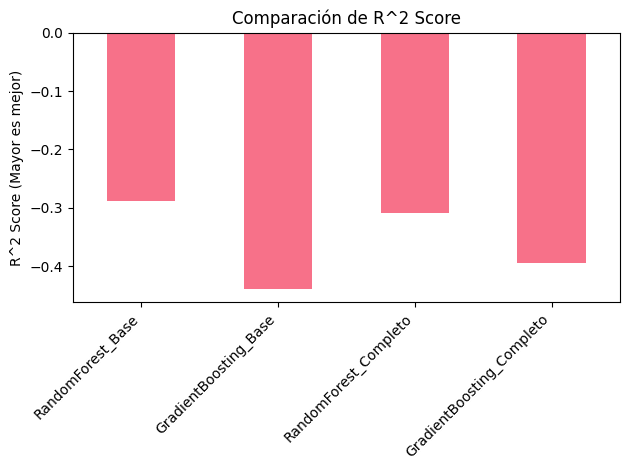

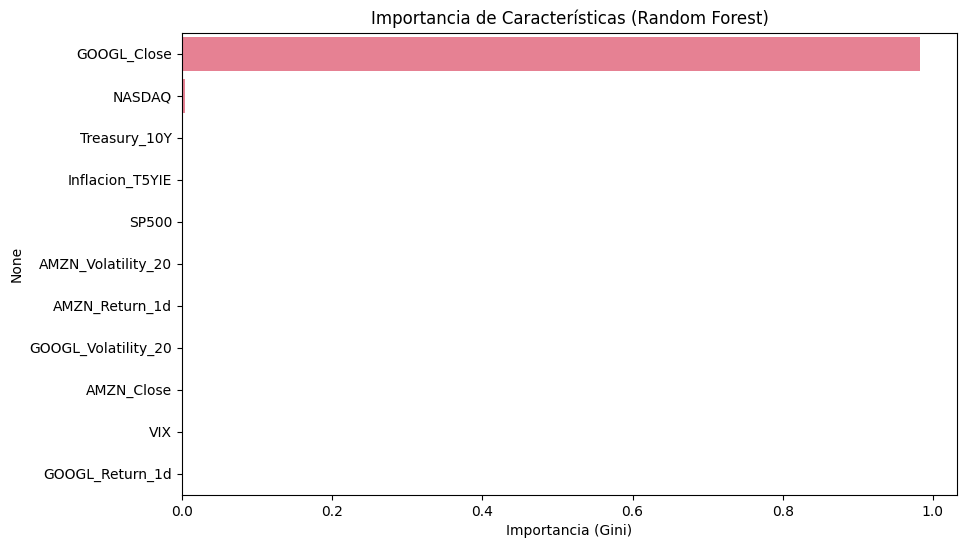


Generando Gráfico de Dependencia Parcial para 'Treasury_10Y'...


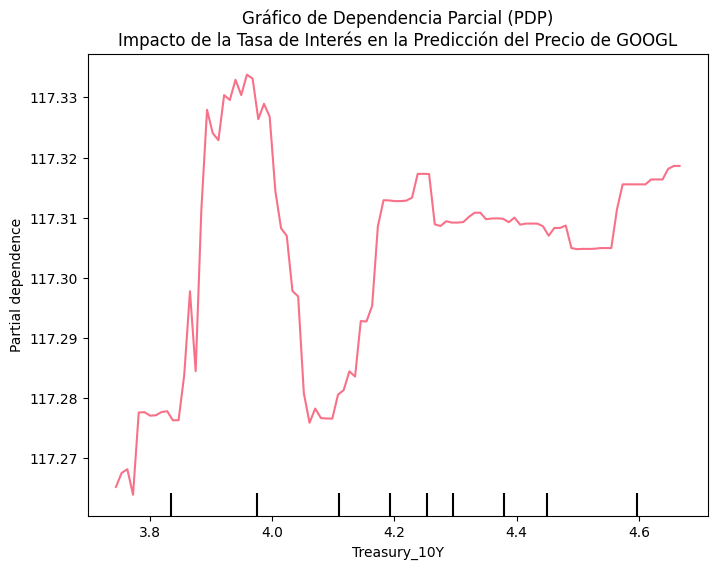


Calculando y graficando valores SHAP...


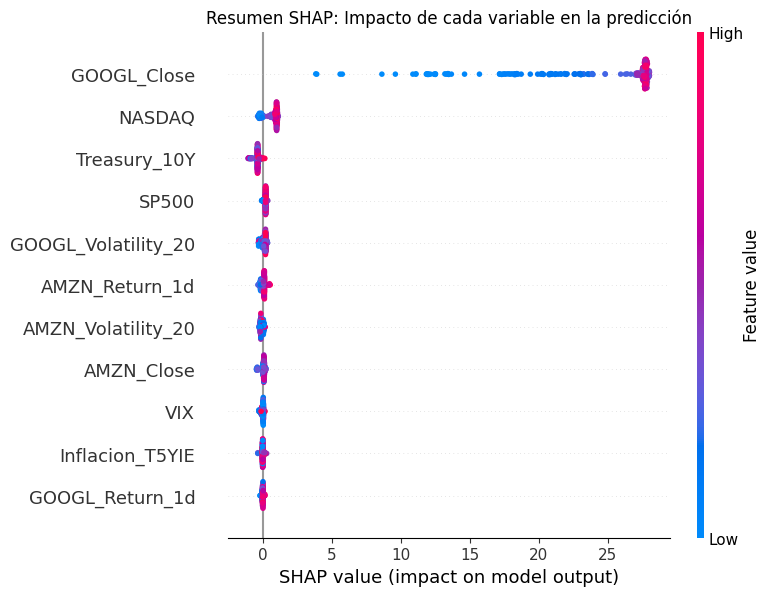

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# --- 1. Carga y Preparación de Datos ---
# Asumo que tu dataset se llama 'dataset_completo_google_amazon.csv'
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- Feature Engineering (Sugerencia) ---
# Es crucial crear features que los modelos puedan usar, especialmente lags.
# Vamos a predecir el precio de GOOGL de mañana usando la info de hoy.
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df.dropna(inplace=True) # Eliminar la última fila que ahora tiene un NaN en el target

# Definir variables predictoras
# Añadir más lags o indicadores técnicos aquí si lo deseas
features_tecnicas = ['GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']
features_macro_sin_interes = ['VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
feature_interes = ['Treasury_10Y']

# Conjunto de features BASE (sin tasa de interés)
features_base = features_tecnicas + features_macro_sin_interes
# Conjunto de features COMPLETO (con tasa de interés)
features_completo = features_tecnicas + features_macro_sin_interes + feature_interes

X_base = df[features_base]
X_completo = df[features_completo]
y = df['GOOGL_Target']

# División de datos (respetando la serie temporal)
# 70% train, 15% validation, 15% test
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_base_train, X_base_test = X_base[:train_size], X_base[train_size:]
X_completo_train, X_completo_test = X_completo[:train_size], X_completo[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# --- 2. Entrenamiento y Evaluación de Modelos ---

# Diccionario para almacenar resultados
resultados = {}

def entrenar_y_evaluar(modelo, X_train, y_train, X_test, y_test, nombre_modelo, nombre_feature_set):
    """Función para entrenar, predecir y guardar métricas."""
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    key = f"{nombre_modelo}_{nombre_feature_set}"
    resultados[key] = {'MSE': mse, 'R2': r2, 'modelo': modelo} # Guardamos el modelo entrenado

    print(f"Resultados para {key}:")
    print(f"  - Mean Squared Error: {mse:.4f}")
    print(f"  - R^2 Score: {r2:.4f}\n")

# Modelos a probar
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

# --- Paso 1 y 2: Entrenar Modelo Base y Modelo Completo ---
print("--- Entrenando modelos SIN tasa de interés (Base) ---")
entrenar_y_evaluar(rf, X_base_train, y_train, X_base_test, y_test, 'RandomForest', 'Base')
entrenar_y_evaluar(gb, X_base_train, y_train, X_base_test, y_test, 'GradientBoosting', 'Base')

print("--- Entrenando modelos CON tasa de interés (Completo) ---")
entrenar_y_evaluar(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_completo_train, y_train, X_completo_test, y_test, 'RandomForest', 'Completo')
entrenar_y_evaluar(GradientBoostingRegressor(n_estimators=100, random_state=42), X_completo_train, y_train, X_completo_test, y_test, 'GradientBoosting', 'Completo')


# --- 3. Comparación de Rendimiento ---
df_resultados = pd.DataFrame(resultados).T[['MSE', 'R2']]
print("\n--- Tabla Comparativa de Rendimiento ---")
print(df_resultados)

# Visualización de la comparación
df_resultados['R2'].plot(kind='bar', title='Comparación de R^2 Score')
plt.ylabel('R^2 Score (Mayor es mejor)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 4. Análisis de Importancia de Características ---
modelo_completo_rf = resultados['RandomForest_Completo']['modelo']

# Gini Importance (Mean Decrease in Impurity)
importances = modelo_completo_rf.feature_importances_
feature_names = X_completo.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=forest_importances, y=forest_importances.index)
plt.title('Importancia de Características (Random Forest)')
plt.xlabel('Importancia (Gini)')
plt.show()

# --- 5. Análisis de Dependencia Parcial (PDP) y SHAP ---
# Esto es CLAVE para probar la relación inversa

# Partial Dependence Plot (PDP)
print("\nGenerando Gráfico de Dependencia Parcial para 'Treasury_10Y'...")
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    modelo_completo_rf,
    X_completo_test,
    features=['Treasury_10Y'], # La característica de interés
    ax=ax
)
ax.set_title("Gráfico de Dependencia Parcial (PDP)\nImpacto de la Tasa de Interés en la Predicción del Precio de GOOGL")
ax.set_ylabel("Predicción del Precio (Dependencia)")
plt.show()

# SHAP (SHapley Additive exPlanations) - Análisis más profundo
print("\nCalculando y graficando valores SHAP...")
explainer = shap.TreeExplainer(modelo_completo_rf)
shap_values = explainer.shap_values(X_completo_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_completo_test, plot_type="dot", show=False)
plt.title("Resumen SHAP: Impacto de cada variable en la predicción")
plt.show()

--- Entrenando modelos SIN tasa de interés (Base) ---
Resultados para RandomForest_Base:
  - Mean Squared Error: 421.0957
  - R^2 Score: -0.2876

Resultados para GradientBoosting_Base:
  - Mean Squared Error: 470.8481
  - R^2 Score: -0.4397

--- Entrenando modelos CON tasa de interés (Completo) ---
Resultados para RandomForest_Completo:
  - Mean Squared Error: 428.0248
  - R^2 Score: -0.3088

Resultados para GradientBoosting_Completo:
  - Mean Squared Error: 456.2321
  - R^2 Score: -0.3950


--- Tabla Comparativa de Rendimiento (Markdown) ---
|                           |     MSE |        R2 |
|:--------------------------|--------:|----------:|
| RandomForest_Base         | 421.096 | -0.287597 |
| GradientBoosting_Base     | 470.848 | -0.439726 |
| RandomForest_Completo     | 428.025 | -0.308784 |
| GradientBoosting_Completo | 456.232 | -0.395034 |


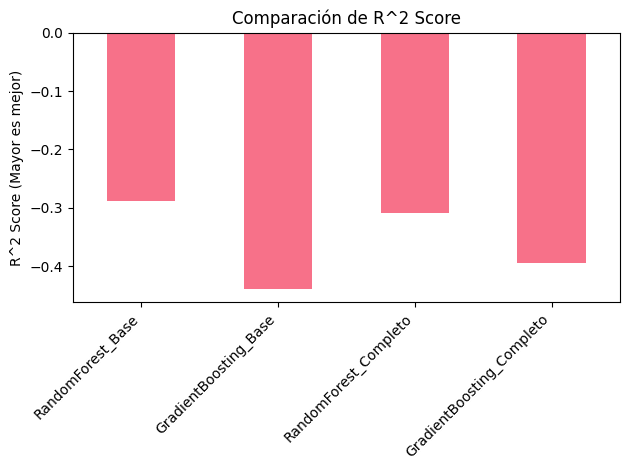


--- Analizando importancia de características para el modelo: GradientBoosting_Completo ---

--- Tabla de Importancia de Características (Markdown) ---
| Característica      |   Importancia |   Porcentaje |
|:--------------------|--------------:|-------------:|
| GOOGL_Close         |   0.988777    |   98.8777    |
| NASDAQ              |   0.0037462   |    0.37462   |
| SP500               |   0.0018384   |    0.18384   |
| Treasury_10Y        |   0.00126865  |    0.126865  |
| AMZN_Volatility_20  |   0.000894324 |    0.0894324 |
| GOOGL_Volatility_20 |   0.000816974 |    0.0816974 |
| AMZN_Close          |   0.000657957 |    0.0657957 |
| Inflacion_T5YIE     |   0.00065261  |    0.065261  |
| GOOGL_Return_1d     |   0.000520272 |    0.0520272 |
| AMZN_Return_1d      |   0.000495477 |    0.0495477 |
| VIX                 |   0.000332477 |    0.0332477 |


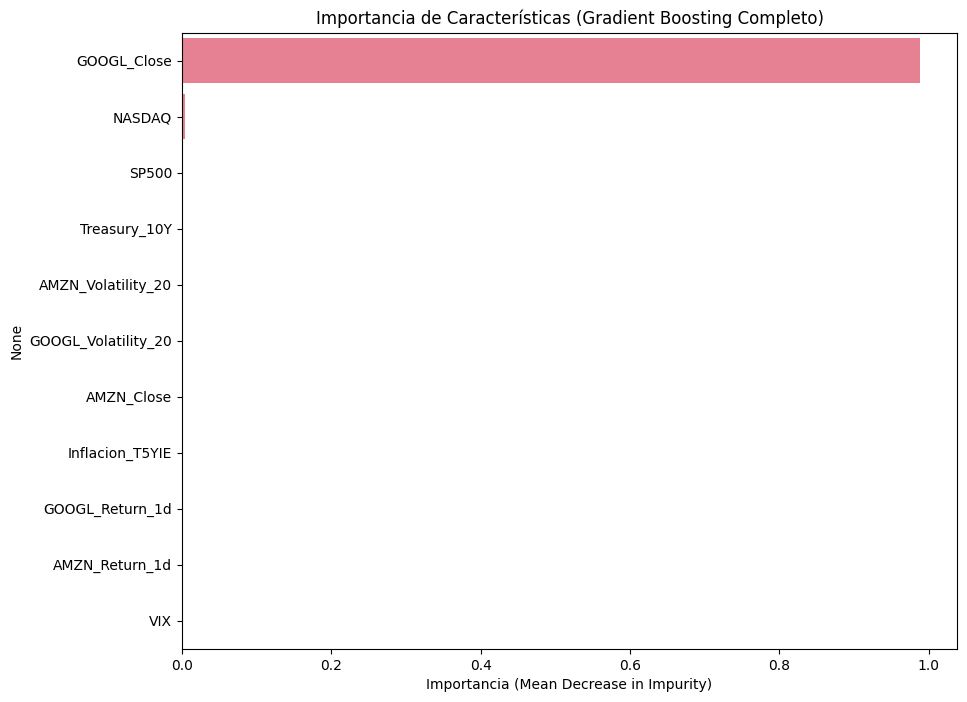


Generando Gráfico de Dependencia Parcial para 'Treasury_10Y'...


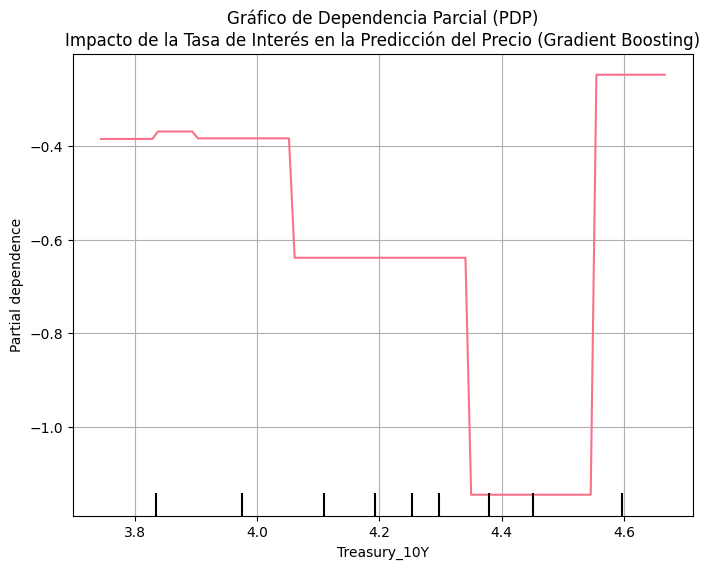


Calculando y graficando valores SHAP...


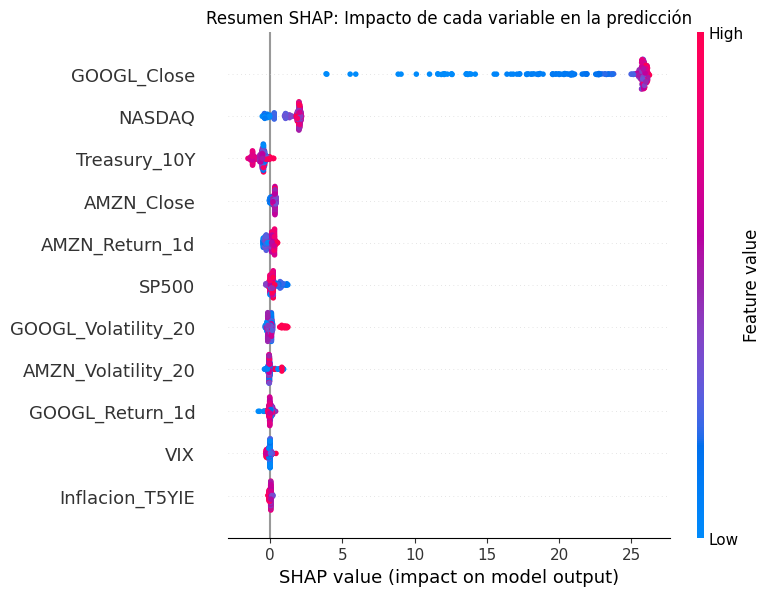

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# --- 1. Carga y Preparación de Datos ---
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- Feature Engineering ---
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df.dropna(inplace=True)

# Definir variables predictoras
features_tecnicas = ['GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']
features_macro_sin_interes = ['VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
feature_interes = ['Treasury_10Y']

features_base = features_tecnicas + features_macro_sin_interes
features_completo = features_tecnicas + features_macro_sin_interes + feature_interes

X_base = df[features_base]
X_completo = df[features_completo]
y = df['GOOGL_Target']

# División de datos (respetando la serie temporal)
train_size = int(len(df) * 0.7)
X_base_train, X_base_test = X_base[:train_size], X_base[train_size:]
X_completo_train, X_completo_test = X_completo[:train_size], X_completo[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# --- 2. Entrenamiento y Evaluación de Modelos ---
resultados = {}

def entrenar_y_evaluar(modelo, X_train, y_train, X_test, y_test, nombre_modelo, nombre_feature_set):
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    key = f"{nombre_modelo}_{nombre_feature_set}"
    resultados[key] = {'MSE': mse, 'R2': r2, 'modelo': modelo}
    print(f"Resultados para {key}:")
    print(f"  - Mean Squared Error: {mse:.4f}")
    print(f"  - R^2 Score: {r2:.4f}\n")

# Modelos a probar
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
rf_completo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb_completo = GradientBoostingRegressor(n_estimators=100, random_state=42)

print("--- Entrenando modelos SIN tasa de interés (Base) ---")
entrenar_y_evaluar(rf_base, X_base_train, y_train, X_base_test, y_test, 'RandomForest', 'Base')
entrenar_y_evaluar(gb_base, X_base_train, y_train, X_base_test, y_test, 'GradientBoosting', 'Base')

print("--- Entrenando modelos CON tasa de interés (Completo) ---")
entrenar_y_evaluar(rf_completo, X_completo_train, y_train, X_completo_test, y_test, 'RandomForest', 'Completo')
entrenar_y_evaluar(gb_completo, X_completo_train, y_train, X_completo_test, y_test, 'GradientBoosting', 'Completo')


# --- 3. Comparación de Rendimiento ---
df_resultados = pd.DataFrame(resultados).T[['MSE', 'R2']]
print("\n--- Tabla Comparativa de Rendimiento (Markdown) ---")
print(df_resultados.to_markdown())

# Visualización de la comparación
df_resultados['R2'].plot(kind='bar', title='Comparación de R^2 Score')
plt.ylabel('R^2 Score (Mayor es mejor)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 4. Análisis de Importancia de Características ---
# <--- CAMBIO CLAVE: Usamos el modelo GradientBoosting_Completo porque fue el que mejoró con la variable.
modelo_analisis = resultados['GradientBoosting_Completo']['modelo']
print(f"\n--- Analizando importancia de características para el modelo: GradientBoosting_Completo ---")

importances = modelo_analisis.feature_importances_
feature_names = X_completo.columns
gb_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Crear DataFrame para la tabla
df_importances = pd.DataFrame({'Característica': gb_importances.index, 'Importancia': gb_importances.values})
df_importances['Porcentaje'] = (df_importances['Importancia'] / df_importances['Importancia'].sum()) * 100

print("\n--- Tabla de Importancia de Características (Markdown) ---")
print(df_importances.to_markdown(index=False))

# Gráfico de la importancia
plt.figure(figsize=(10, 8))
sns.barplot(x=gb_importances, y=gb_importances.index)
plt.title('Importancia de Características (Gradient Boosting Completo)')
plt.xlabel('Importancia (Mean Decrease in Impurity)')
plt.show()

# --- 5. Análisis de Dependencia Parcial (PDP) y SHAP ---
# <--- CAMBIO CLAVE: Usamos el mismo modelo (GradientBoosting_Completo) para consistencia.

# Partial Dependence Plot (PDP)
print("\nGenerando Gráfico de Dependencia Parcial para 'Treasury_10Y'...")
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    modelo_analisis,
    X_completo_test,
    features=['Treasury_10Y'],
    ax=ax
)
ax.set_title("Gráfico de Dependencia Parcial (PDP)\nImpacto de la Tasa de Interés en la Predicción del Precio (Gradient Boosting)")
ax.set_ylabel("Predicción del Precio (Dependencia)")
plt.grid(True)
plt.show()

# SHAP (SHapley Additive exPlanations)
print("\nCalculando y graficando valores SHAP...")
# Para Gradient Boosting, SHAP es muy eficiente.
explainer = shap.TreeExplainer(modelo_analisis)
shap_values = explainer.shap_values(X_completo_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_completo_test, plot_type="dot", show=False)
plt.title("Resumen SHAP: Impacto de cada variable en la predicción")
plt.show()

==================== ANÁLISIS PARA GOOGLE ====================

--- Fase de Entrenamiento y Evaluación ---

Modelos SIN tasa de interés (Base):
Resultados para RandomForest_Base: MSE=421.0957, R^2=-0.2876
Resultados para GradientBoosting_Base: MSE=470.8481, R^2=-0.4397

Modelos CON tasa de interés (Completo):
Resultados para RandomForest_Completo: MSE=428.0248, R^2=-0.3088
Resultados para GradientBoosting_Completo: MSE=456.2321, R^2=-0.3950

--- Tabla Comparativa de Rendimiento (Markdown) ---
|                           |     MSE |        R2 |
|:--------------------------|--------:|----------:|
| RandomForest_Base         | 421.096 | -0.287597 |
| GradientBoosting_Base     | 470.848 | -0.439726 |
| RandomForest_Completo     | 428.025 | -0.308784 |
| GradientBoosting_Completo | 456.232 | -0.395034 |


==================== ANÁLISIS DE INTERPRETABILIDAD PARA: RandomForest_Completo ====================

--- Tabla de Importancia de Características para RandomForest_Completo (Markdown) ---
|

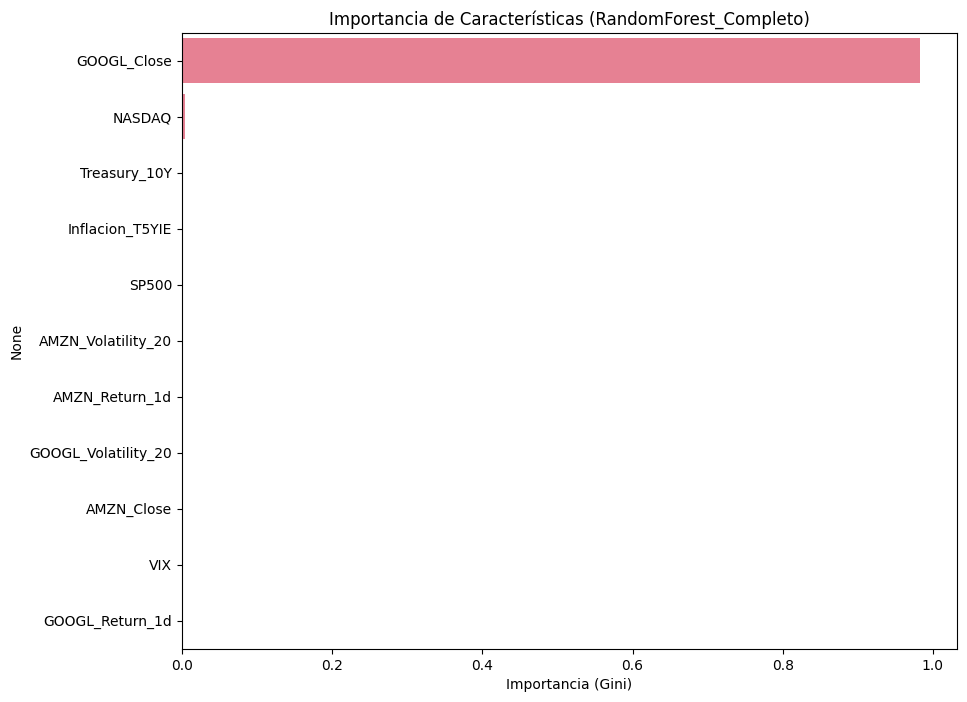


Generando PDP para 'Treasury_10Y' en modelo RandomForest_Completo...


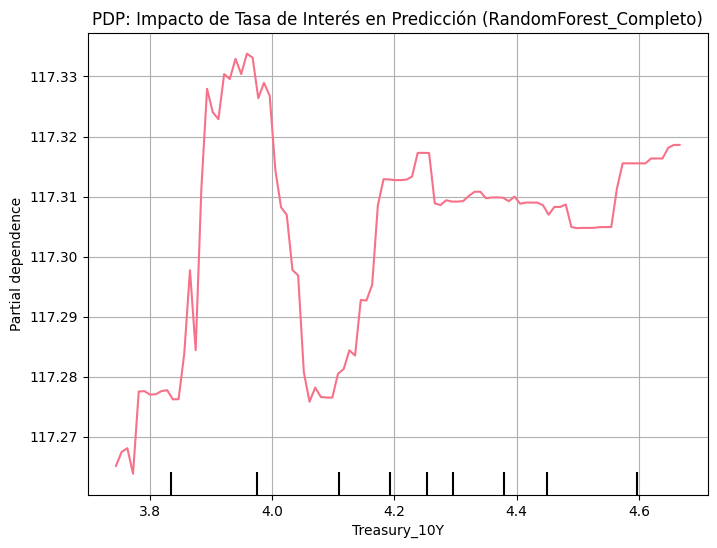


Calculando y graficando valores SHAP para RandomForest_Completo...


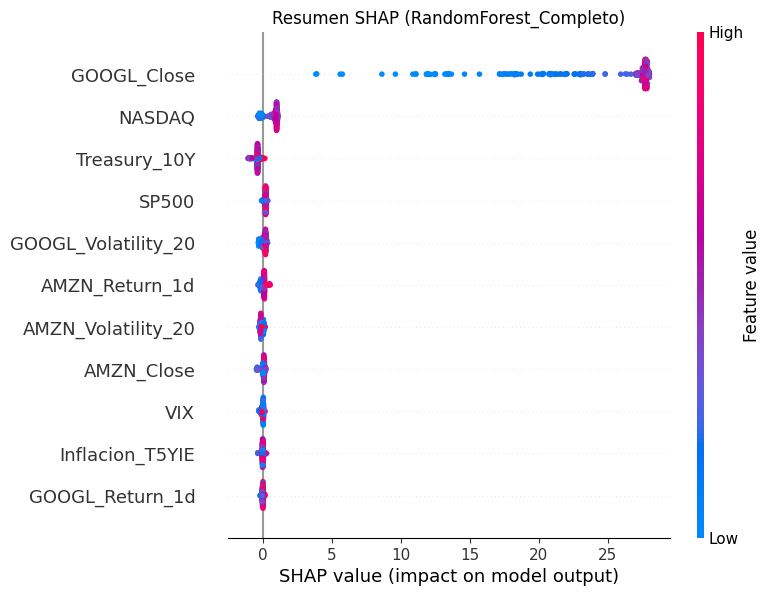



==================== ANÁLISIS DE INTERPRETABILIDAD PARA: GradientBoosting_Completo ====================

--- Tabla de Importancia de Características para GradientBoosting_Completo (Markdown) ---
| Característica      |   Importancia |   Porcentaje |
|:--------------------|--------------:|-------------:|
| GOOGL_Close         |   0.988777    |   98.8777    |
| NASDAQ              |   0.0037462   |    0.37462   |
| SP500               |   0.0018384   |    0.18384   |
| Treasury_10Y        |   0.00126865  |    0.126865  |
| AMZN_Volatility_20  |   0.000894324 |    0.0894324 |
| GOOGL_Volatility_20 |   0.000816974 |    0.0816974 |
| AMZN_Close          |   0.000657957 |    0.0657957 |
| Inflacion_T5YIE     |   0.00065261  |    0.065261  |
| GOOGL_Return_1d     |   0.000520272 |    0.0520272 |
| AMZN_Return_1d      |   0.000495477 |    0.0495477 |
| VIX                 |   0.000332477 |    0.0332477 |


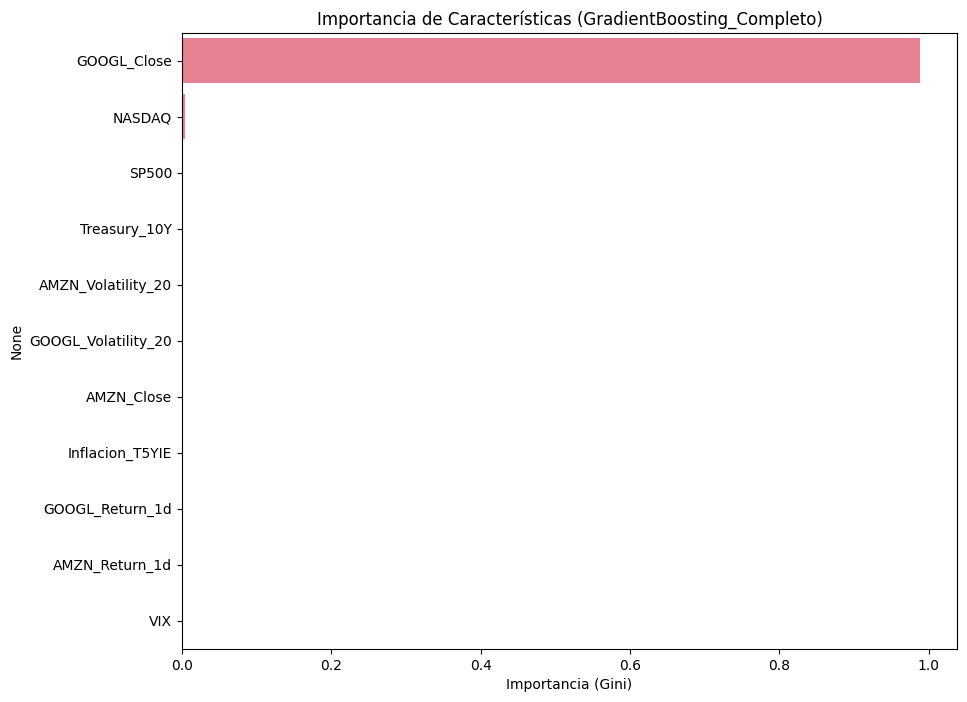


Generando PDP para 'Treasury_10Y' en modelo GradientBoosting_Completo...


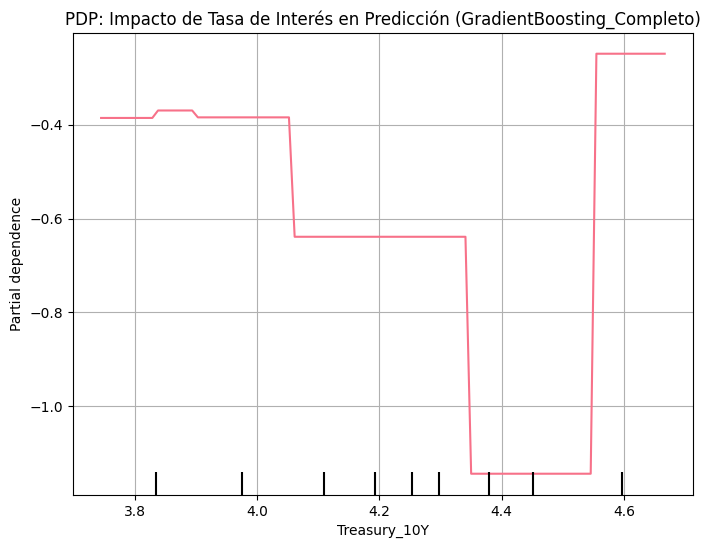


Calculando y graficando valores SHAP para GradientBoosting_Completo...


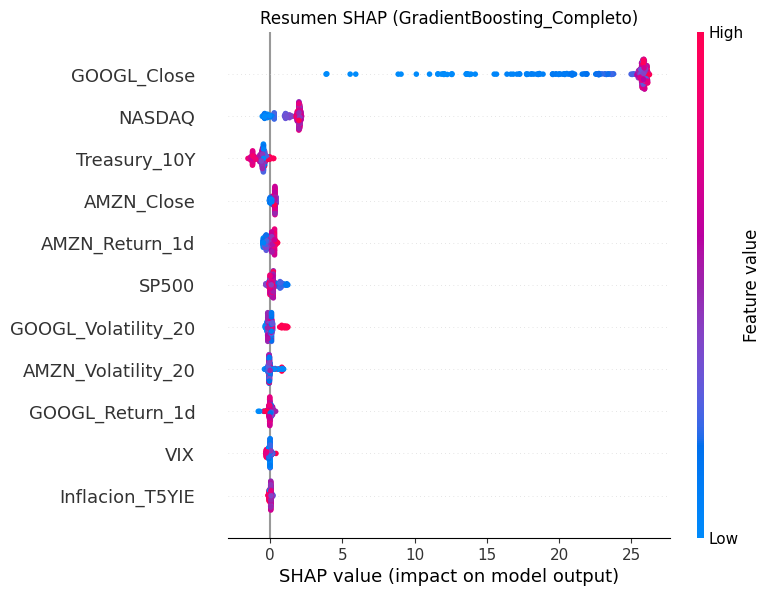

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# --- 1. Carga y Preparación de Datos ---
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- Feature Engineering para Google ---
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df.dropna(inplace=True)

# Definir variables predictoras
features_tecnicas = ['GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']
features_macro_sin_interes = ['VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
feature_interes = ['Treasury_10Y']

features_base = features_tecnicas + features_macro_sin_interes
features_completo = features_tecnicas + features_macro_sin_interes + feature_interes

X_base = df[features_base]
X_completo = df[features_completo]
y = df['GOOGL_Target']

# División de datos
train_size = int(len(df) * 0.7)
X_base_train, X_base_test = X_base.iloc[:train_size], X_base.iloc[train_size:]
X_completo_train, X_completo_test = X_completo.iloc[:train_size], X_completo.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]


# --- 2. Entrenamiento y Evaluación de Modelos ---
resultados = {}
print(f"{'='*20} ANÁLISIS PARA GOOGLE {'='*20}\n")
print("--- Fase de Entrenamiento y Evaluación ---")

def entrenar_y_evaluar(modelo, X_train, y_train, X_test, y_test, nombre_modelo, nombre_feature_set):
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    key = f"{nombre_modelo}_{nombre_feature_set}"
    resultados[key] = {'MSE': mse, 'R2': r2, 'modelo': modelo}
    print(f"Resultados para {key}: MSE={mse:.4f}, R^2={r2:.4f}")

# Modelos a probar
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
rf_completo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb_completo = GradientBoostingRegressor(n_estimators=100, random_state=42)

print("\nModelos SIN tasa de interés (Base):")
entrenar_y_evaluar(rf_base, X_base_train, y_train, X_base_test, y_test, 'RandomForest', 'Base')
entrenar_y_evaluar(gb_base, X_base_train, y_train, X_base_test, y_test, 'GradientBoosting', 'Base')

print("\nModelos CON tasa de interés (Completo):")
entrenar_y_evaluar(rf_completo, X_completo_train, y_train, X_completo_test, y_test, 'RandomForest', 'Completo')
entrenar_y_evaluar(gb_completo, X_completo_train, y_train, X_completo_test, y_test, 'GradientBoosting', 'Completo')


# --- 3. Comparación de Rendimiento ---
df_resultados = pd.DataFrame(resultados).T[['MSE', 'R2']]
print("\n--- Tabla Comparativa de Rendimiento (Markdown) ---")
print(df_resultados.to_markdown())


# --- 4. FUNCIÓN PARA ANÁLISIS DE INTERPRETABILIDAD ---

def analizar_interpretabilidad(nombre_modelo_completo, resultados, X_test):
    """
    Genera todos los análisis de interpretabilidad para un modelo dado.
    """
    print(f"\n\n{'='*20} ANÁLISIS DE INTERPRETABILIDAD PARA: {nombre_modelo_completo} {'='*20}")

    modelo_analisis = resultados[nombre_modelo_completo]['modelo']

    # 4.1 Importancia de Características
    importances = modelo_analisis.feature_importances_
    feature_importances = pd.Series(importances, index=X_test.columns).sort_values(ascending=False)

    df_importances = pd.DataFrame({'Característica': feature_importances.index, 'Importancia': feature_importances.values})
    df_importances['Porcentaje'] = (df_importances['Importancia'] / df_importances['Importancia'].sum()) * 100

    print(f"\n--- Tabla de Importancia de Características para {nombre_modelo_completo} (Markdown) ---")
    print(df_importances.to_markdown(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x=feature_importances, y=feature_importances.index)
    plt.title(f'Importancia de Características ({nombre_modelo_completo})')
    plt.xlabel('Importancia (Gini)')
    plt.show()

    # 4.2 Partial Dependence Plot (PDP)
    print(f"\nGenerando PDP para 'Treasury_10Y' en modelo {nombre_modelo_completo}...")
    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(
        modelo_analisis, X_test, features=['Treasury_10Y'], ax=ax)
    ax.set_title(f"PDP: Impacto de Tasa de Interés en Predicción ({nombre_modelo_completo})")
    ax.set_ylabel("Predicción del Precio (Dependencia)")
    plt.grid(True)
    plt.show()

    # 4.3 SHAP (SHapley Additive exPlanations)
    print(f"\nCalculando y graficando valores SHAP para {nombre_modelo_completo}...")
    explainer = shap.TreeExplainer(modelo_analisis)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
    plt.title(f"Resumen SHAP ({nombre_modelo_completo})")
    plt.show()

# --- 5. Ejecutar Análisis de Interpretabilidad para ambos modelos completos ---
analizar_interpretabilidad('RandomForest_Completo', resultados, X_completo_test)
analizar_interpretabilidad('GradientBoosting_Completo', resultados, X_completo_test)


==================== INICIANDO ANÁLISIS PARA: AMZN (Objetivo Específico 1) ====================


--- PASO 1: Entrenando modelo SIN tasa de interés (Base) para AMAZON ---
Resultados para AMZN - GradientBoosting_Base:
  - MSE: 186.6386, R^2: 0.6267

--- PASO 2: Entrenando modelo CON tasa de interés (Completo) para AMAZON ---
Resultados para AMZN - GradientBoosting_Completo:
  - MSE: 296.3761, R^2: 0.4073

--- PASO 3: Tabla Comparativa de Rendimiento para AMAZON (Markdown) ---
|                           |     MSE |       R2 |
|:--------------------------|--------:|---------:|
| GradientBoosting_Base     | 186.639 | 0.626728 |
| GradientBoosting_Completo | 296.376 | 0.407256 |

--- PASO 4: Tabla de Importancia de Características para AMAZON (Markdown) ---
| Característica      |   Importancia |   Porcentaje |
|:--------------------|--------------:|-------------:|
| AMZN_Close          |   0.970422    |   97.0422    |
| Treasury_10Y        |   0.0243368   |    2.43368   |
| NASDAQ       

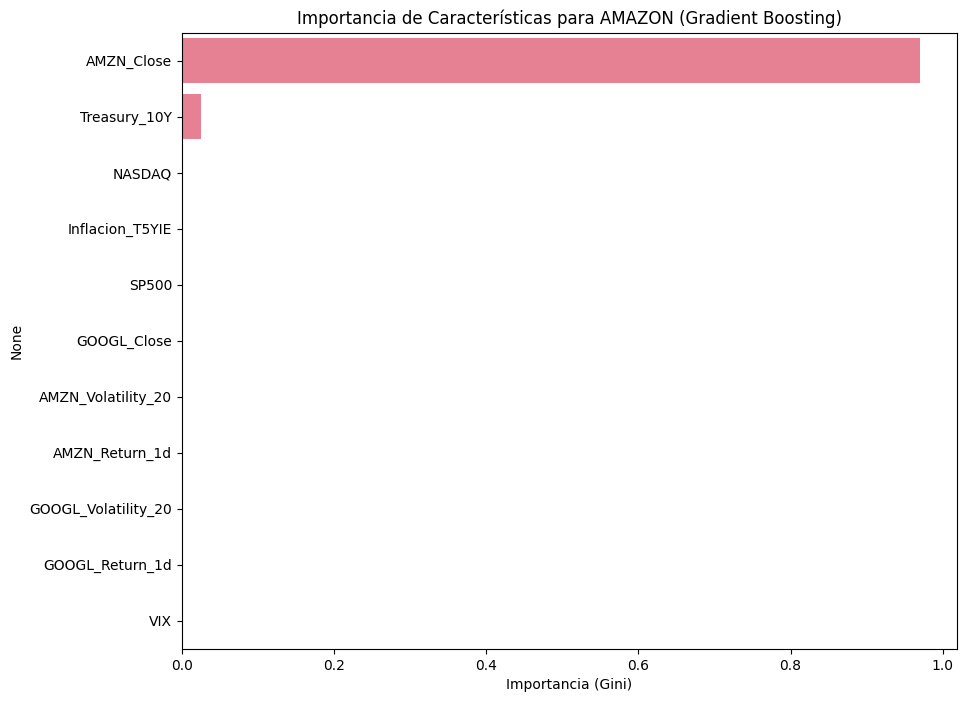


--- PASO 5: Análisis de Dependencia e Impacto para AMAZON ---


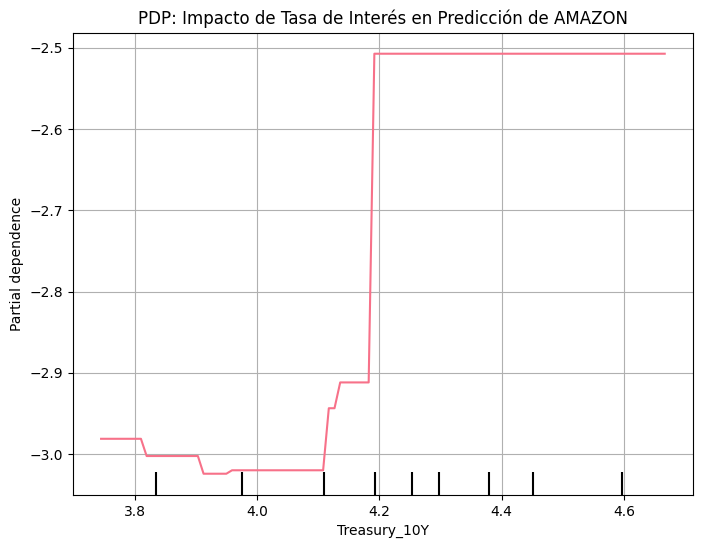

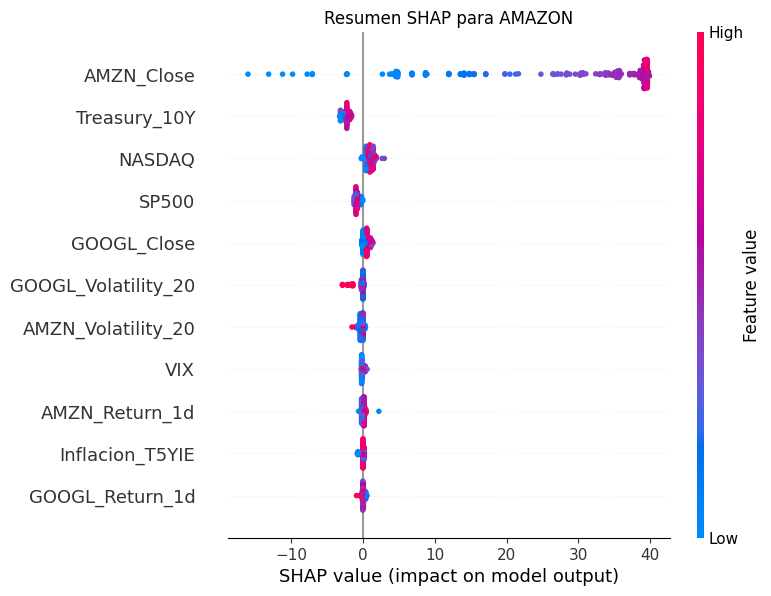

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# --- 1. Carga y Preparación de Datos ---
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- Feature Engineering ---
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)
df.dropna(inplace=True)

# --- 2. Función de Análisis Modular para AMAZON ---
def analizar_accion_amazon(df):
    """
    Realiza el análisis completo para AMAZON enfocado en el Objetivo Específico 1.
    """
    ticker_symbol = 'AMZN'
    print(f"\n{'='*20} INICIANDO ANÁLISIS PARA: {ticker_symbol} (Objetivo Específico 1) {'='*20}\n")

    # Definir variables predictoras y objetivo
    target_col = f'{ticker_symbol}_Target'
    # Incluimos todas las variables relevantes como predictores
    features_tecnicas = [
        'GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d',
        'GOOGL_Volatility_20', 'AMZN_Volatility_20'
    ]
    features_macro = ['VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
    feature_interes = ['Treasury_10Y']

    # Se usan todas las variables excepto la de interés para el modelo base
    features_base = features_tecnicas + features_macro
    features_completo = features_tecnicas + features_macro + feature_interes

    X_base = df[features_base]
    X_completo = df[features_completo]
    y = df[target_col]

    # División de datos
    train_size = int(len(df) * 0.7)
    X_base_train, X_base_test = X_base.iloc[:train_size], X_base.iloc[train_size:]
    X_completo_train, X_completo_test = X_completo.iloc[:train_size], X_completo.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    # --- Entrenamiento y Evaluación ---
    resultados = {}

    def entrenar_y_evaluar(modelo, X_train, y_train, X_test, y_test, nombre_modelo, nombre_feature_set):
        modelo.fit(X_train, y_train)
        preds = modelo.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        key = f"{nombre_modelo}_{nombre_feature_set}"
        resultados[key] = {'MSE': mse, 'R2': r2, 'modelo': modelo}
        print(f"Resultados para {ticker_symbol} - {key}:")
        print(f"  - MSE: {mse:.4f}, R^2: {r2:.4f}")

    # Usaremos solo Gradient Boosting, que funcionó mejor para Google
    gb_base_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb_completo_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

    print("\n--- PASO 1: Entrenando modelo SIN tasa de interés (Base) para AMAZON ---")
    entrenar_y_evaluar(gb_base_model, X_base_train, y_train, X_base_test, y_test, 'GradientBoosting', 'Base')

    print("\n--- PASO 2: Entrenando modelo CON tasa de interés (Completo) para AMAZON ---")
    entrenar_y_evaluar(gb_completo_model, X_completo_train, y_train, X_completo_test, y_test, 'GradientBoosting', 'Completo')

    # --- Comparación de Rendimiento ---
    df_resultados = pd.DataFrame(resultados).T[['MSE', 'R2']]
    print(f"\n--- PASO 3: Tabla Comparativa de Rendimiento para AMAZON (Markdown) ---")
    print(df_resultados.to_markdown())

    # --- Análisis de Importancia de Características ---
    modelo_analisis = resultados['GradientBoosting_Completo']['modelo']
    importances = modelo_analisis.feature_importances_
    gb_importances = pd.Series(importances, index=X_completo.columns).sort_values(ascending=False)

    df_importances = pd.DataFrame({'Característica': gb_importances.index, 'Importancia': gb_importances.values})
    df_importances['Porcentaje'] = (df_importances['Importancia'] / df_importances['Importancia'].sum()) * 100

    print(f"\n--- PASO 4: Tabla de Importancia de Características para AMAZON (Markdown) ---")
    print(df_importances.to_markdown(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x=gb_importances, y=gb_importances.index)
    plt.title(f'Importancia de Características para AMAZON (Gradient Boosting)')
    plt.xlabel('Importancia (Gini)')
    plt.show()

    # --- PDP y SHAP ---
    print("\n--- PASO 5: Análisis de Dependencia e Impacto para AMAZON ---")
    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(
        modelo_analisis, X_completo_test, features=['Treasury_10Y'], ax=ax)
    ax.set_title(f"PDP: Impacto de Tasa de Interés en Predicción de AMAZON")
    ax.set_ylabel("Predicción del Precio (Dependencia)")
    plt.grid(True)
    plt.show()

    explainer = shap.TreeExplainer(modelo_analisis)
    shap_values = explainer.shap_values(X_completo_test)

    shap.summary_plot(shap_values, X_completo_test, plot_type="dot", show=False)
    plt.title(f"Resumen SHAP para AMAZON")
    plt.show()

# --- Ejecutar análisis para AMAZON ---
analizar_accion_amazon(df.copy())

==================== ANÁLISIS PARA AMAZON ====================

--- Fase de Entrenamiento y Evaluación ---

Modelos SIN tasa de interés (Base):
Resultados para RandomForest_Base: MSE=203.5824, R^2=0.5928
Resultados para GradientBoosting_Base: MSE=186.6386, R^2=0.6267

Modelos CON tasa de interés (Completo):
Resultados para RandomForest_Completo: MSE=200.2588, R^2=0.5995
Resultados para GradientBoosting_Completo: MSE=296.3761, R^2=0.4073

--- Tabla Comparativa de Rendimiento para AMAZON (Markdown) ---
|                           |     MSE |       R2 |
|:--------------------------|--------:|---------:|
| RandomForest_Base         | 203.582 | 0.592841 |
| GradientBoosting_Base     | 186.639 | 0.626728 |
| RandomForest_Completo     | 200.259 | 0.599488 |
| GradientBoosting_Completo | 296.376 | 0.407256 |


==================== ANÁLISIS DE INTERPRETABILIDAD PARA: RandomForest_Completo (AMAZON) ====================

--- Tabla de Importancia de Características para RandomForest_Completo (Mark

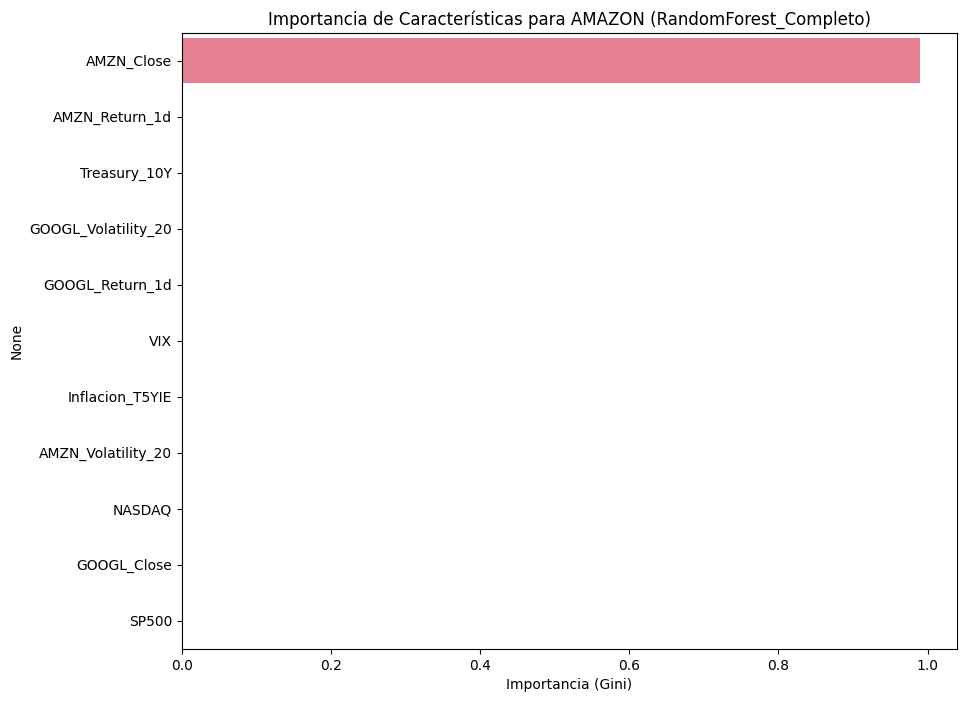


Generando PDP para 'Treasury_10Y' en modelo RandomForest_Completo...


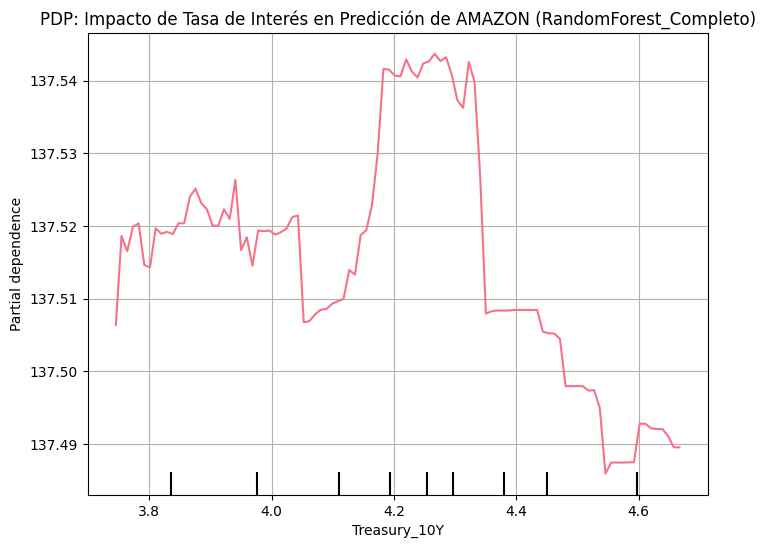


Calculando y graficando valores SHAP para RandomForest_Completo...


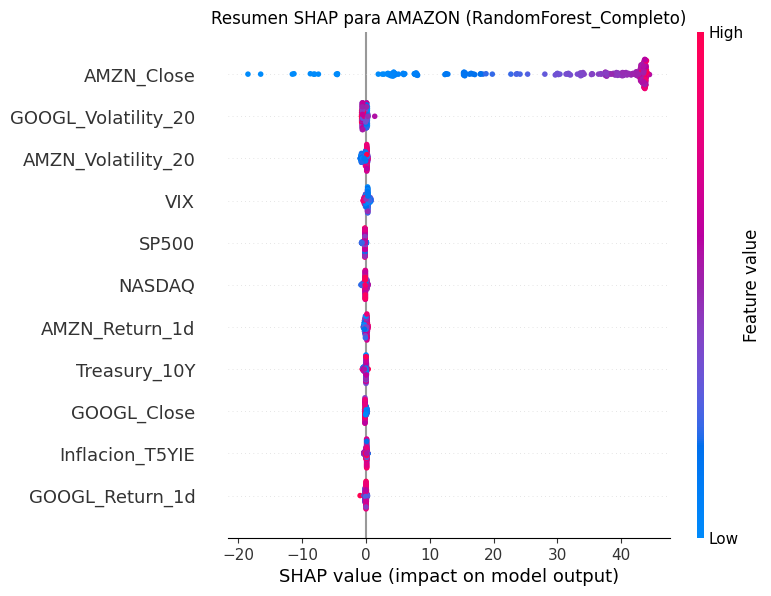



==================== ANÁLISIS DE INTERPRETABILIDAD PARA: GradientBoosting_Completo (AMAZON) ====================

--- Tabla de Importancia de Características para GradientBoosting_Completo (Markdown) ---
| Característica      |   Importancia |   Porcentaje |
|:--------------------|--------------:|-------------:|
| AMZN_Close          |   0.970422    |   97.0422    |
| Treasury_10Y        |   0.0243368   |    2.43368   |
| NASDAQ              |   0.00156893  |    0.156893  |
| Inflacion_T5YIE     |   0.000660447 |    0.0660447 |
| SP500               |   0.000574739 |    0.0574739 |
| GOOGL_Close         |   0.000456639 |    0.0456639 |
| AMZN_Volatility_20  |   0.000431906 |    0.0431906 |
| AMZN_Return_1d      |   0.000424291 |    0.0424291 |
| GOOGL_Volatility_20 |   0.000417276 |    0.0417276 |
| GOOGL_Return_1d     |   0.000384672 |    0.0384672 |
| VIX                 |   0.000322149 |    0.0322149 |


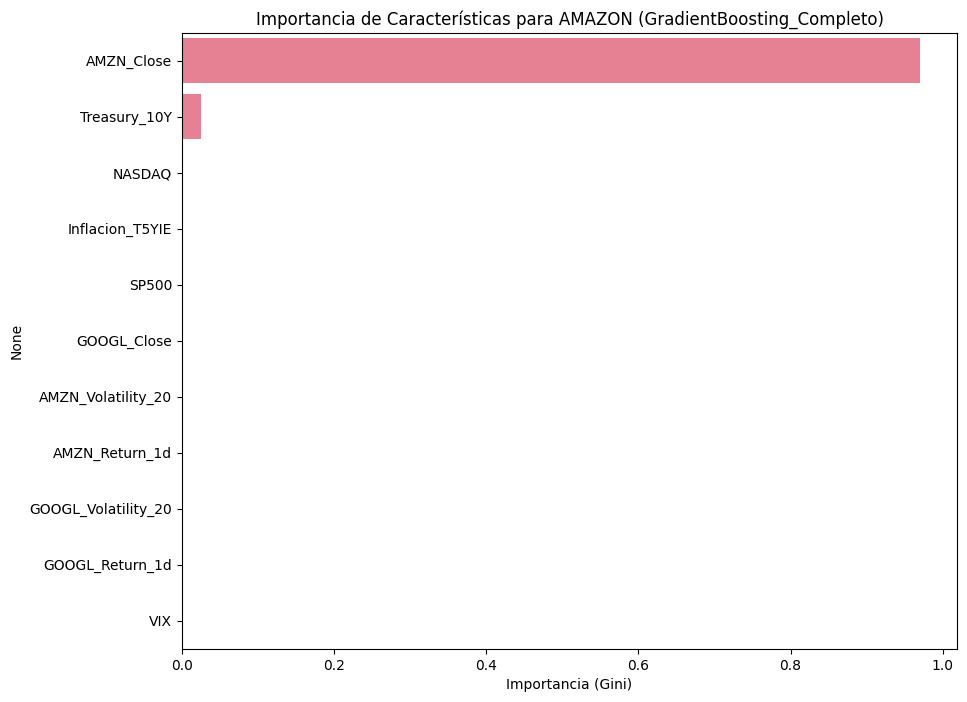


Generando PDP para 'Treasury_10Y' en modelo GradientBoosting_Completo...


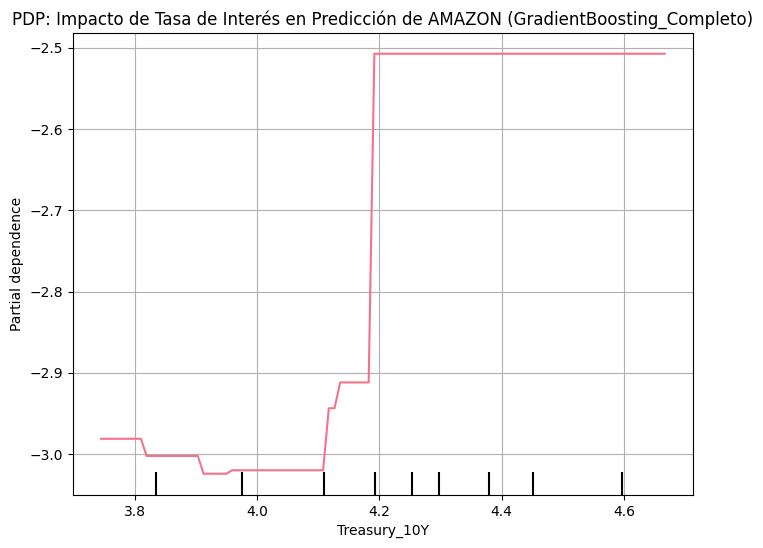


Calculando y graficando valores SHAP para GradientBoosting_Completo...


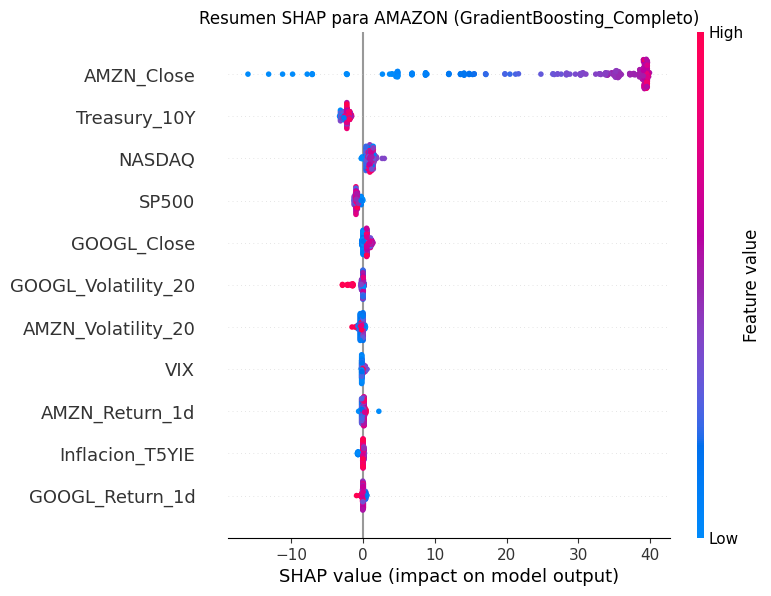

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# --- 1. Carga y Preparación de Datos ---
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- Feature Engineering para Amazon ---
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)
df.dropna(inplace=True)

# Definir variables predictoras
features_tecnicas = ['GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']
features_macro_sin_interes = ['VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
feature_interes = ['Treasury_10Y']

features_base = features_tecnicas + features_macro_sin_interes
features_completo = features_tecnicas + features_macro_sin_interes + feature_interes

X_base = df[features_base]
X_completo = df[features_completo]
y = df['AMZN_Target']

# División de datos
train_size = int(len(df) * 0.7)
X_base_train, X_base_test = X_base.iloc[:train_size], X_base.iloc[train_size:]
X_completo_train, X_completo_test = X_completo.iloc[:train_size], X_completo.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]


# --- 2. Entrenamiento y Evaluación de Modelos para AMAZON ---
resultados = {}
print(f"{'='*20} ANÁLISIS PARA AMAZON {'='*20}\n")
print("--- Fase de Entrenamiento y Evaluación ---")

def entrenar_y_evaluar(modelo, X_train, y_train, X_test, y_test, nombre_modelo, nombre_feature_set):
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    key = f"{nombre_modelo}_{nombre_feature_set}"
    resultados[key] = {'MSE': mse, 'R2': r2, 'modelo': modelo}
    print(f"Resultados para {key}: MSE={mse:.4f}, R^2={r2:.4f}")

# Modelos a probar
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
rf_completo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb_completo = GradientBoostingRegressor(n_estimators=100, random_state=42)

print("\nModelos SIN tasa de interés (Base):")
entrenar_y_evaluar(rf_base, X_base_train, y_train, X_base_test, y_test, 'RandomForest', 'Base')
entrenar_y_evaluar(gb_base, X_base_train, y_train, X_base_test, y_test, 'GradientBoosting', 'Base')

print("\nModelos CON tasa de interés (Completo):")
entrenar_y_evaluar(rf_completo, X_completo_train, y_train, X_completo_test, y_test, 'RandomForest', 'Completo')
entrenar_y_evaluar(gb_completo, X_completo_train, y_train, X_completo_test, y_test, 'GradientBoosting', 'Completo')


# --- 3. Comparación de Rendimiento ---
df_resultados = pd.DataFrame(resultados).T[['MSE', 'R2']]
print("\n--- Tabla Comparativa de Rendimiento para AMAZON (Markdown) ---")
print(df_resultados.to_markdown())


# --- 4. FUNCIÓN PARA ANÁLISIS DE INTERPRETABILIDAD ---

def analizar_interpretabilidad(nombre_modelo_completo, resultados, X_test):
    """
    Genera todos los análisis de interpretabilidad para un modelo dado.
    """
    print(f"\n\n{'='*20} ANÁLISIS DE INTERPRETABILIDAD PARA: {nombre_modelo_completo} (AMAZON) {'='*20}")

    modelo_analisis = resultados[nombre_modelo_completo]['modelo']

    # 4.1 Importancia de Características
    importances = modelo_analisis.feature_importances_
    feature_importances = pd.Series(importances, index=X_test.columns).sort_values(ascending=False)

    df_importances = pd.DataFrame({'Característica': feature_importances.index, 'Importancia': feature_importances.values})
    df_importances['Porcentaje'] = (df_importances['Importancia'] / df_importances['Importancia'].sum()) * 100

    print(f"\n--- Tabla de Importancia de Características para {nombre_modelo_completo} (Markdown) ---")
    print(df_importances.to_markdown(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x=feature_importances, y=feature_importances.index)
    plt.title(f'Importancia de Características para AMAZON ({nombre_modelo_completo})')
    plt.xlabel('Importancia (Gini)')
    plt.show()

    # 4.2 Partial Dependence Plot (PDP)
    print(f"\nGenerando PDP para 'Treasury_10Y' en modelo {nombre_modelo_completo}...")
    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(
        modelo_analisis, X_test, features=['Treasury_10Y'], ax=ax)
    ax.set_title(f"PDP: Impacto de Tasa de Interés en Predicción de AMAZON ({nombre_modelo_completo})")
    ax.set_ylabel("Predicción del Precio (Dependencia)")
    plt.grid(True)
    plt.show()

    # 4.3 SHAP (SHapley Additive exPlanations)
    print(f"\nCalculando y graficando valores SHAP para {nombre_modelo_completo}...")
    explainer = shap.TreeExplainer(modelo_analisis)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
    plt.title(f"Resumen SHAP para AMAZON ({nombre_modelo_completo})")
    plt.show()

# --- 5. Ejecutar Análisis de Interpretabilidad para ambos modelos completos de AMAZON ---
analizar_interpretabilidad('RandomForest_Completo', resultados, X_completo_test)
analizar_interpretabilidad('GradientBoosting_Completo', resultados, X_completo_test)

In [94]:
import pandas as pd
from joblib import dump, load # Usaremos joblib para guardar y cargar los modelos entrenados
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- 0. Asumimos que los modelos ya fueron entrenados como en los scripts anteriores ---
# Si no los tienes en memoria, necesitarías re-entrenarlos primero.
# Por simplicidad, aquí re-entrenamos rápidamente.

# --- Carga y Preparación de Datos ---
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')

# --- Feature Engineering ---
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)
df.dropna(inplace=True)

# Definir variables predictoras
features_tecnicas = ['GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d', 'GOOGL_Volatility_20', 'AMZN_Volatility_20']
features_macro = ['VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
feature_interes = ['Treasury_10Y']
features_completo = features_tecnicas + features_macro + feature_interes

# --- Entrenamiento de los 4 modelos necesarios ---
# Modelos para Google
X_googl = df[features_completo]
y_googl = df['GOOGL_Target']
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_googl, y_googl)
gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_googl, y_googl)

# Modelos para Amazon
X_amzn = df[features_completo]
y_amzn = df['AMZN_Target']
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_amzn, y_amzn)
gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_amzn, y_amzn)


# --- 1. Definir el Punto de Partida y los Escenarios ---
# Usamos la última fila de datos como base
last_data_point = df[features_completo].iloc[-1]
print("--- Punto de Partida (Datos del último día) ---")
print(last_data_point)

# Crear DataFrames para los escenarios
escenario1_df = pd.DataFrame([last_data_point.to_dict()])
escenario2_df = pd.DataFrame([last_data_point.to_dict()])

# Modificar la tasa de interés en cada escenario
escenario1_df['Treasury_10Y'] = 4.745  # Aumento de Tensión
escenario2_df['Treasury_10Y'] = 4.345  # Relajación Monetaria

print("\n--- Escenario 1: Aumento de Tasa de Interés ---")
print(escenario1_df)
print("\n--- Escenario 2: Disminución de Tasa de Interés ---")
print(escenario2_df)


# --- 2. Realizar Pronósticos ---
pronosticos = {}

# Pronósticos para Google
pronosticos['GOOGL'] = {
    'Escenario 1 (Sube Tasa) - RF': rf_googl.predict(escenario1_df)[0],
    'Escenario 2 (Baja Tasa) - RF': rf_googl.predict(escenario2_df)[0],
    'Escenario 1 (Sube Tasa) - GB': gb_googl.predict(escenario1_df)[0],
    'Escenario 2 (Baja Tasa) - GB': gb_googl.predict(escenario2_df)[0]
}

# Pronósticos para Amazon
pronosticos['AMZN'] = {
    'Escenario 1 (Sube Tasa) - RF': rf_amzn.predict(escenario1_df)[0],
    'Escenario 2 (Baja Tasa) - RF': rf_amzn.predict(escenario2_df)[0],
    'Escenario 1 (Sube Tasa) - GB': rf_amzn.predict(escenario1_df)[0],
    'Escenario 2 (Baja Tasa) - GB': rf_amzn.predict(escenario2_df)[0]
}

# --- 3. Presentar Resultados en una Tabla ---
df_pronosticos = pd.DataFrame(pronosticos).T

# Calcular el cambio porcentual para facilitar la interpretación
precio_actual_googl = last_data_point['GOOGL_Close']
precio_actual_amzn = last_data_point['AMZN_Close']

print("\n\n" + "="*20 + " RESULTADOS DE PRONÓSTICOS " + "="*20)
print(f"\nPrecio Actual GOOGL: ${precio_actual_googl:.2f}")
print(f"Precio Actual AMZN: ${precio_actual_amzn:.2f}\n")


df_pronosticos_final = pd.DataFrame.from_dict(pronosticos, orient='index')
print("--- Tabla de Pronósticos de Precios (USD) ---")
print(df_pronosticos_final.round(2))

# Convertir a tabla Markdown
print("\n--- Tabla de Pronósticos (Markdown) ---")
print(df_pronosticos_final.round(2).to_markdown())

--- Punto de Partida (Datos del último día) ---
GOOGL_Close             192.538
AMZN_Close              223.750
GOOGL_Return_1d          -0.015
AMZN_Return_1d           -0.015
GOOGL_Volatility_20      10.235
AMZN_Volatility_20        6.737
VIX                      15.950
SP500                  5970.840
NASDAQ                19722.029
Inflacion_T5YIE           2.380
Treasury_10Y              4.619
Name: 2024-12-27 00:00:00, dtype: float64

--- Escenario 1: Aumento de Tasa de Interés ---
   GOOGL_Close  AMZN_Close  GOOGL_Return_1d  AMZN_Return_1d  \
0      192.538     223.750           -0.015          -0.015   

   GOOGL_Volatility_20  AMZN_Volatility_20    VIX    SP500    NASDAQ  \
0               10.235               6.737 15.950 5970.840 19722.029   

   Inflacion_T5YIE  Treasury_10Y  
0            2.380         4.745  

--- Escenario 2: Disminución de Tasa de Interés ---
   GOOGL_Close  AMZN_Close  GOOGL_Return_1d  AMZN_Return_1d  \
0      192.538     223.750           -0.015        

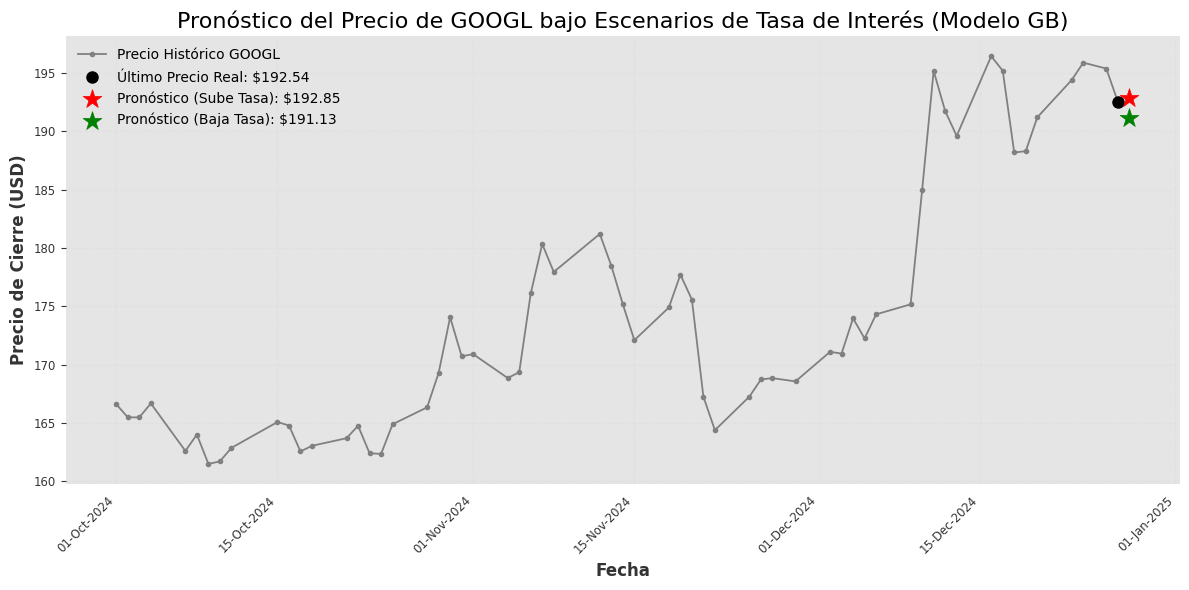

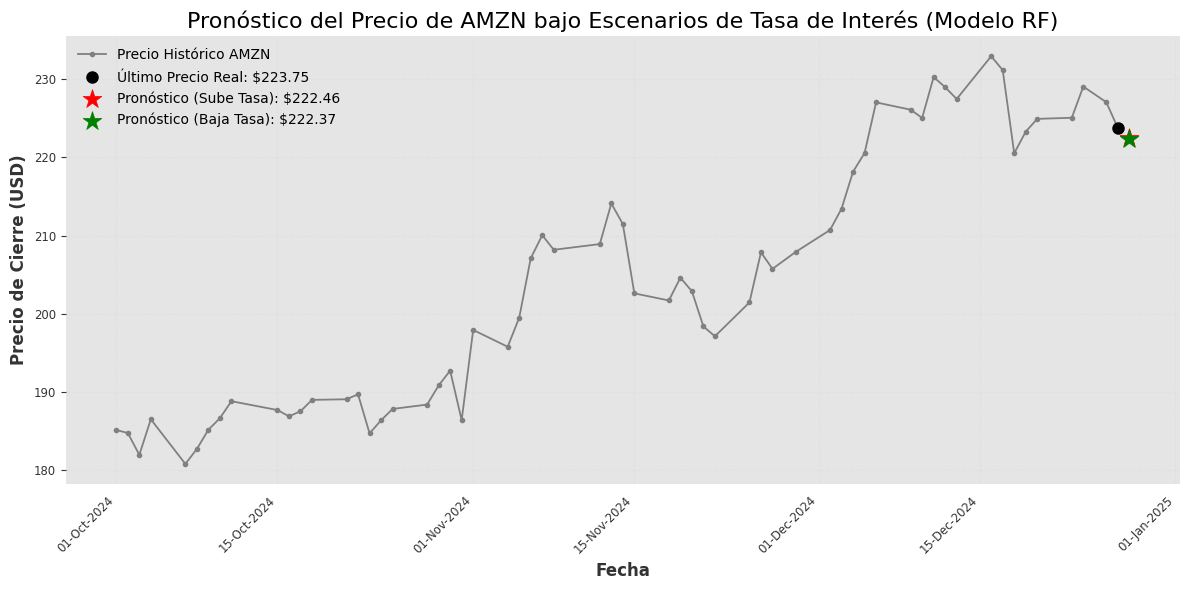

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# (Asegúrate de que todo el código anterior se ha ejecutado y tienes df_pronosticos_final)
# ...
# df_pronosticos_final = pd.DataFrame.from_dict(pronosticos, orient='index')
# ...

# --- 4. Visualización de los Pronósticos ---

def graficar_pronosticos(ticker_symbol, df_historico, pronosticos_modelo):
    """
    Grafica la serie de precios histórica y superpone los pronósticos.
    Args:
        ticker_symbol (str): 'GOOGL' o 'AMZN'.
        df_historico (pd.DataFrame): DataFrame con los datos históricos.
        pronosticos_modelo (dict): Diccionario con los pronósticos para la acción.
    """

    # Hacer zoom en los últimos 60 días de datos para mejor visibilidad
    df_zoom = df_historico.iloc[-60:]

    # El punto de pronóstico estará un día después del último dato histórico
    ultimo_dia_historico = df_zoom.index[-1]
    dia_pronostico = ultimo_dia_historico + pd.Timedelta(days=1)

    # Extraer el precio actual para referencia
    precio_actual = df_zoom[f'{ticker_symbol}_Close'].iloc[-1]

    plt.figure(figsize=(12, 6))

    # Graficar la serie histórica
    plt.plot(df_zoom.index, df_zoom[f'{ticker_symbol}_Close'], label=f'Precio Histórico {ticker_symbol}', color='gray', marker='o', markersize=3)

    # Graficar el último punto histórico con un color diferente
    plt.plot(ultimo_dia_historico, precio_actual, 'o', color='black', markersize=8, label=f'Último Precio Real: ${precio_actual:.2f}')

    # --- Añadir los puntos de pronóstico ---
    # Usaremos solo un modelo para no saturar el gráfico.
    # Elegimos el que tuvo mejor comportamiento para cada acción.
    # Para Google -> Gradient Boosting. Para Amazon -> Random Forest.

    if ticker_symbol == 'GOOGL':
        modelo_usado = 'GB'
        pronostico_sube = pronosticos_modelo['Escenario 1 (Sube Tasa) - GB']
        pronostico_baja = pronosticos_modelo['Escenario 2 (Baja Tasa) - GB']
    else: # AMZN
        modelo_usado = 'RF'
        pronostico_sube = pronosticos_modelo['Escenario 1 (Sube Tasa) - RF']
        pronostico_baja = pronosticos_modelo['Escenario 2 (Baja Tasa) - RF']

    # Escenario 1: Sube la Tasa (Impacto negativo esperado)
    plt.scatter(dia_pronostico, pronostico_sube, color='red', marker='*', s=200,
                label=f'Pronóstico (Sube Tasa): ${pronostico_sube:.2f}', zorder=5)

    # Escenario 2: Baja la Tasa (Impacto positivo esperado)
    plt.scatter(dia_pronostico, pronostico_baja, color='green', marker='*', s=200,
                label=f'Pronóstico (Baja Tasa): ${pronostico_baja:.2f}', zorder=5)

    # --- Formato del Gráfico ---
    plt.title(f'Pronóstico del Precio de {ticker_symbol} bajo Escenarios de Tasa de Interés (Modelo {modelo_usado})', fontsize=16)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.xlabel('Fecha', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Formatear el eje X para que las fechas sean legibles
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

# --- Ejecutar la visualización para ambas acciones ---
graficar_pronosticos('GOOGL', df, pronosticos['GOOGL'])
graficar_pronosticos('AMZN', df, pronosticos['AMZN'])

Modelos entrenados con todos los datos.

Generando pronósticos recursivos para 43 días hábiles (Ene-Feb 2025)...


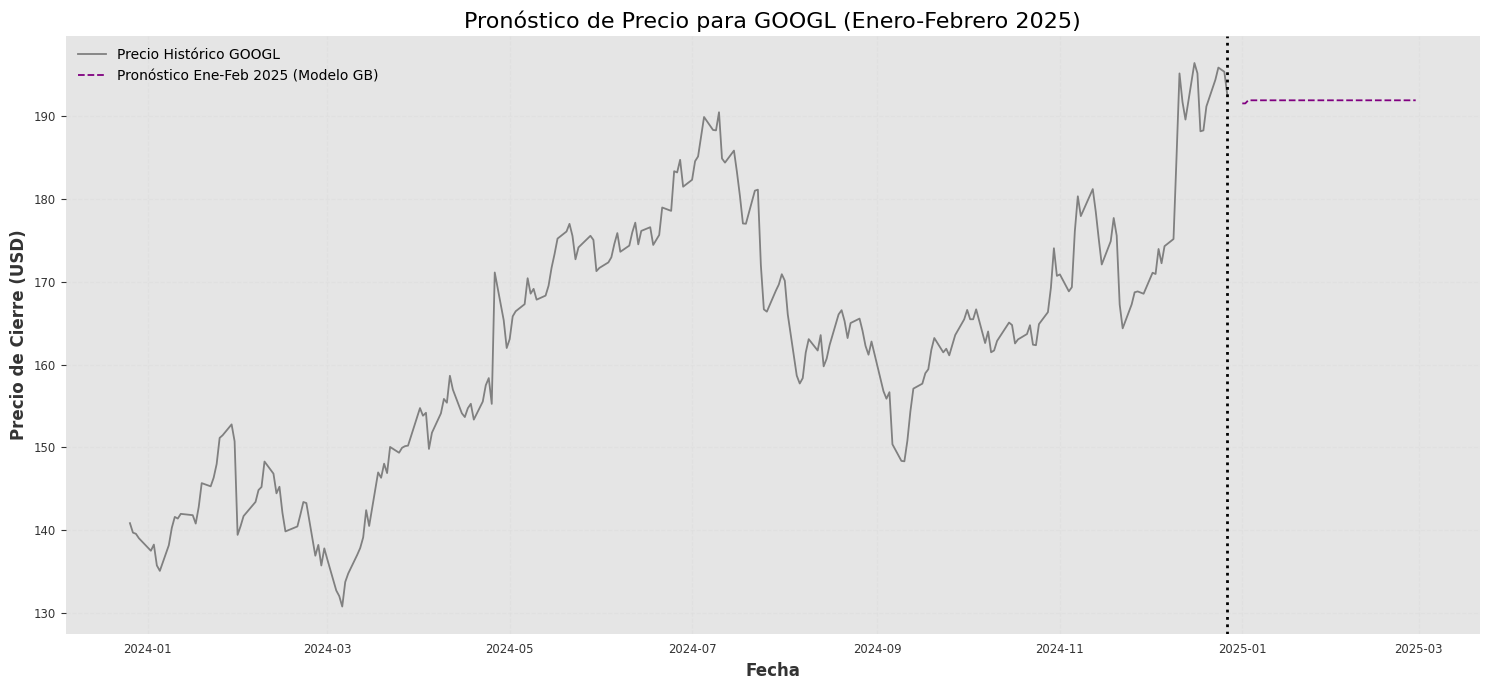

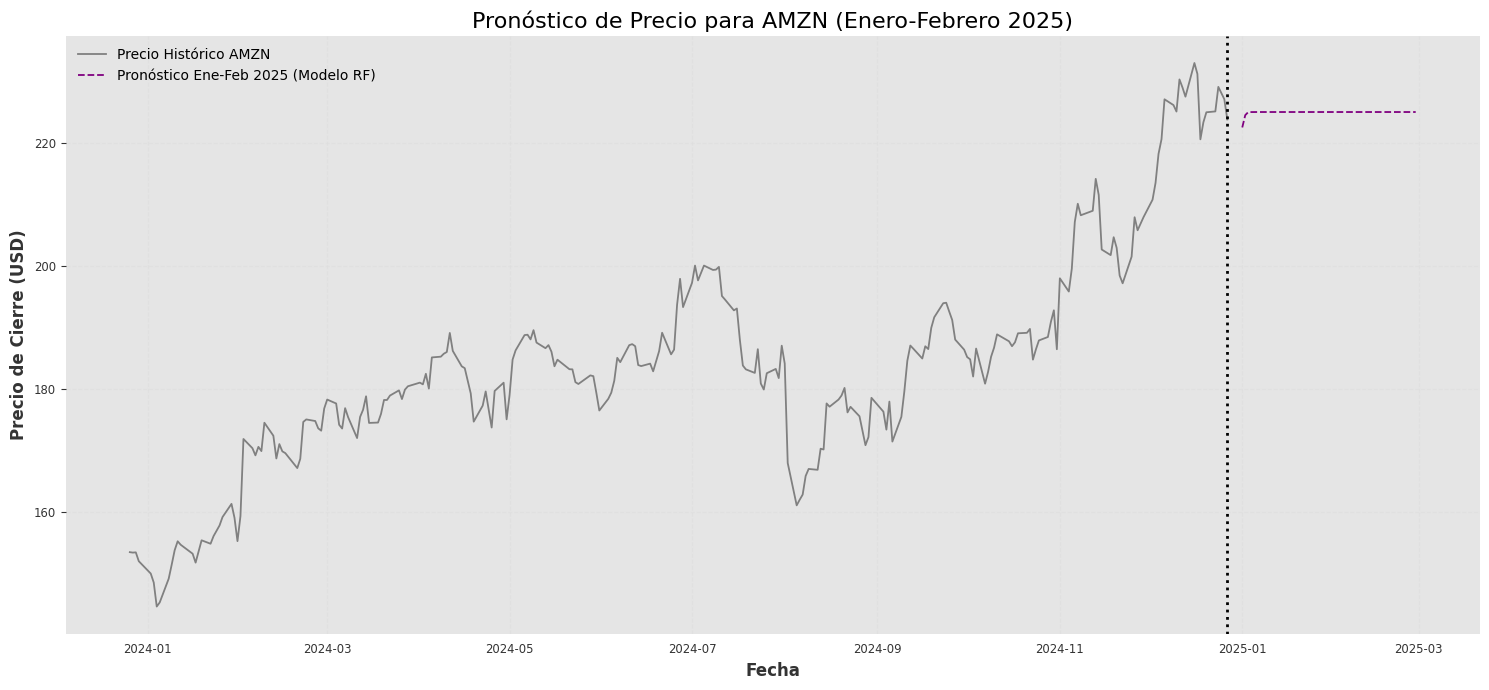

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- 1. Entrenamiento de Modelos (Igual que antes, para tenerlos listos) ---
df_original = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'], index_col='Date')
df = df_original.copy()

# Feature Engineering
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)
df.dropna(inplace=True)

# Definir variables
features_completo = [
    'GOOGL_Close', 'AMZN_Close', 'GOOGL_Return_1d', 'AMZN_Return_1d',
    'GOOGL_Volatility_20', 'AMZN_Volatility_20', 'VIX', 'SP500', 'NASDAQ',
    'Inflacion_T5YIE', 'Treasury_10Y'
]

# Modelos para Google
X_googl = df[features_completo]
y_googl = df['GOOGL_Target']
gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_googl, y_googl)

# Modelos para Amazon
X_amzn = df[features_completo]
y_amzn = df['AMZN_Target']
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_amzn, y_amzn)

print("Modelos entrenados con todos los datos.")

# --- 2. Función de Pronóstico Recursivo ---

def pronostico_recursivo(modelo, datos_iniciales, n_dias, ticker_symbol):
    """
    Genera un pronóstico a N días hacia el futuro de forma recursiva.
    """
    # Asumimos que otras variables (VIX, SP500, etc.) se mantienen constantes en su último valor conocido
    # Esta es una simplificación fuerte necesaria para el pronóstico

    ultimos_datos = datos_iniciales.copy()
    pronosticos = []

    for _ in range(n_dias):
        # Preparar el input para la predicción (un DataFrame de una fila)
        input_df = pd.DataFrame([ultimos_datos])

        # Realizar la predicción
        prediccion = modelo.predict(input_df)[0]
        pronosticos.append(prediccion)

        # Actualizar los datos para la siguiente iteración
        # El precio de cierre predicho se convierte en el nuevo precio de cierre
        nuevo_precio_cierre = prediccion
        retorno_calculado = (nuevo_precio_cierre - ultimos_datos[f'{ticker_symbol}_Close']) / ultimos_datos[f'{ticker_symbol}_Close']

        ultimos_datos[f'{ticker_symbol}_Close'] = nuevo_precio_cierre
        ultimos_datos[f'{ticker_symbol}_Return_1d'] = retorno_calculado
        # Nota: La volatilidad y otras variables complejas no se actualizan dinámicamente aquí.
        # Esto es una simplificación y una limitación del pronóstico.

    return pronosticos

# --- 3. Generar Pronósticos para Enero y Febrero 2025 ---

# Punto de partida: el último día de datos reales
punto_partida = df[features_completo].iloc[-1]
fechas_pronostico = pd.to_datetime(pd.date_range(start='2025-01-01', end='2025-02-28', freq='B')) # 'B' para días hábiles
n_dias_pronostico = len(fechas_pronostico)

print(f"\nGenerando pronósticos recursivos para {n_dias_pronostico} días hábiles (Ene-Feb 2025)...")

# Generar pronósticos
pronosticos_googl = pronostico_recursivo(gb_googl, punto_partida, n_dias_pronostico, 'GOOGL')
pronosticos_amzn = pronostico_recursivo(rf_amzn, punto_partida, n_dias_pronostico, 'AMZN')

# Crear DataFrames con los resultados
df_pronosticos_googl = pd.DataFrame({'Forecast': pronosticos_googl}, index=fechas_pronostico)
df_pronosticos_amzn = pd.DataFrame({'Forecast': pronosticos_amzn}, index=fechas_pronostico)

# --- 4. Visualización de los Pronósticos a Largo Plazo ---

def graficar_pronostico_largo_plazo(ticker_symbol, df_historico, df_pronostico):
    """Grafica la serie histórica y el pronóstico de 2 meses."""

    # Hacer zoom en el último año de datos históricos
    df_zoom = df_historico.iloc[-252:]

    plt.figure(figsize=(15, 7))

    # Graficar la serie histórica
    plt.plot(df_zoom.index, df_zoom[f'{ticker_symbol}_Close'], label=f'Precio Histórico {ticker_symbol}', color='gray')

    # Graficar la serie pronosticada
    plt.plot(df_pronostico.index, df_pronostico['Forecast'],
             label=f'Pronóstico Ene-Feb 2025 (Modelo {"GB" if ticker_symbol=="GOOGL" else "RF"})',
             color='purple', linestyle='--')

    # --- Formato del Gráfico ---
    plt.title(f'Pronóstico de Precio para {ticker_symbol} (Enero-Febrero 2025)', fontsize=16)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.xlabel('Fecha', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axvline(df_zoom.index[-1], color='black', linestyle=':', linewidth=2, label='Inicio del Pronóstico')

    plt.tight_layout()
    plt.show()

graficar_pronostico_largo_plazo('GOOGL', df, df_pronosticos_googl)
graficar_pronostico_largo_plazo('AMZN', df, df_pronosticos_amzn)

## HASTA EL GRAFICO ANTERIOR CONSIDERA EL INFORME DEL OBJETIVO ESPECIFICO NUMERO 1

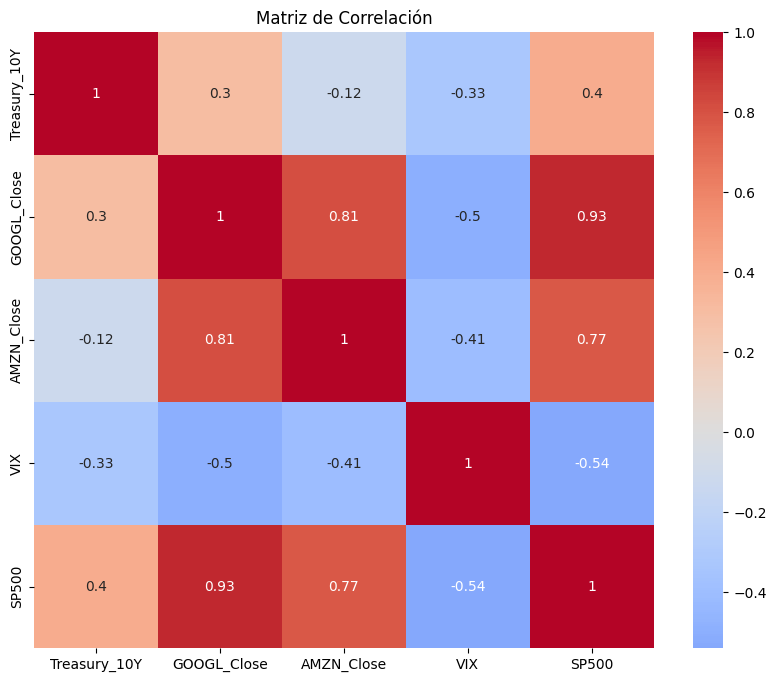

In [13]:
# Matriz de correlación
corr_matrix = df[['Treasury_10Y', 'GOOGL_Close', 'AMZN_Close', 'VIX', 'SP500']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.savefig('corr_matrix.png')
plt.show()

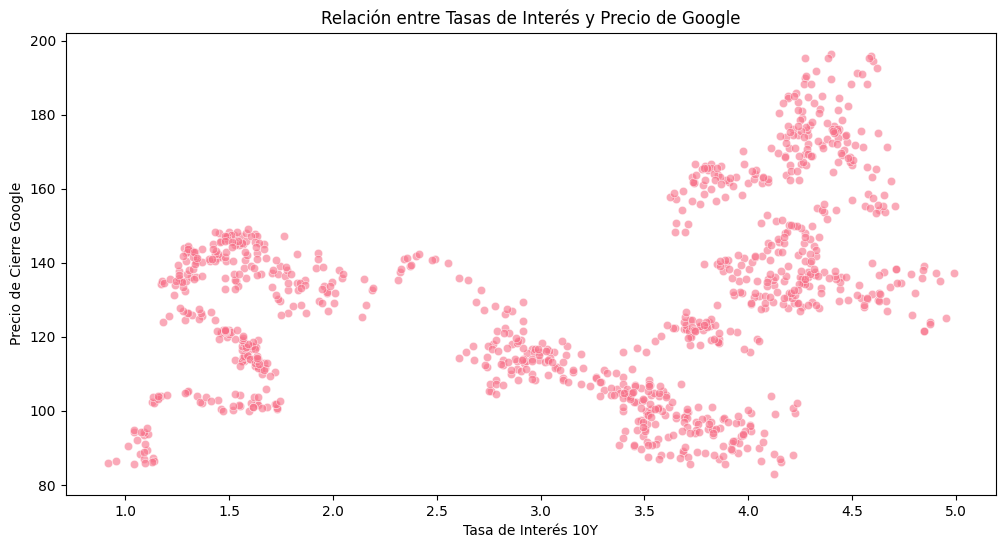

In [14]:
# Relación tasas vs precios
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Treasury_10Y', y='GOOGL_Close', data=df, alpha=0.6)
plt.title('Relación entre Tasas de Interés y Precio de Google')
plt.xlabel('Tasa de Interés 10Y')
plt.ylabel('Precio de Cierre Google')
plt.savefig('scatter_plot.png')
plt.show()

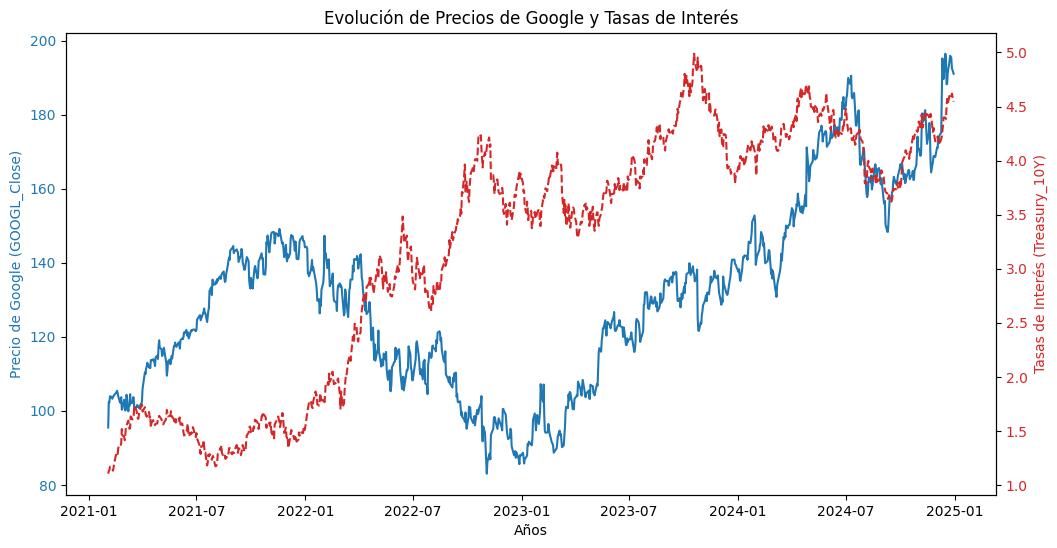

In [ ]:
 # Gráfico para Google
fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:blue'
ax1.set_xlabel('Años')
ax1.set_ylabel('Precio de Google (GOOGL_Close)', color=color)
ax1.plot(df['Date'], df['GOOGL_Close'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Tasas de Interés (Treasury_10Y)', color=color)
ax2.plot(df['Date'], df['Treasury_10Y'], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolución de Precios de Google y Tasas de Interés')
plt.savefig('google_tasas_precios.png')
plt.show()

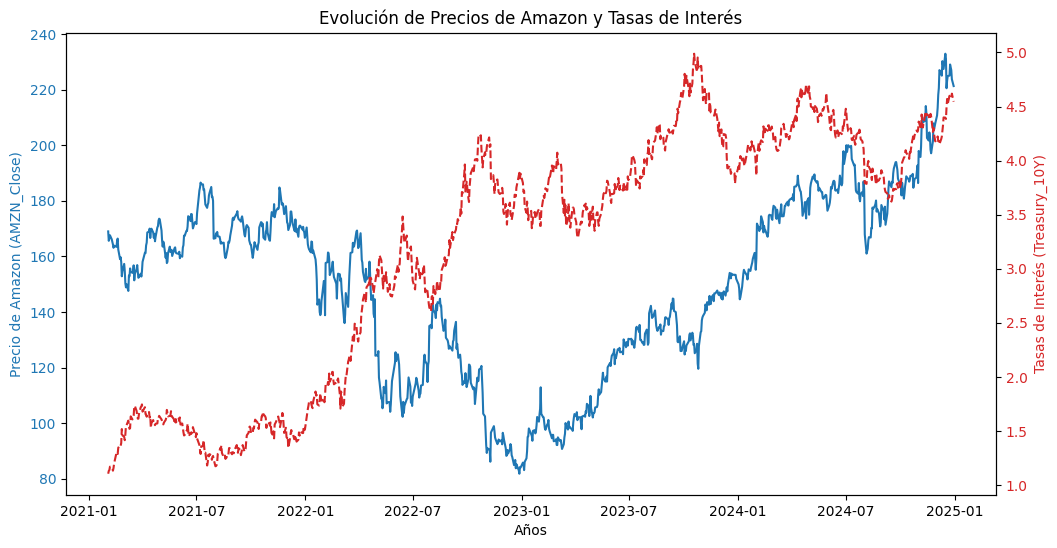

In [ ]:
# Gráfico para Google
fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:blue'
ax1.set_xlabel('Años')
ax1.set_ylabel('Precio de Amazon (AMZN_Close)', color=color)
ax1.plot(df['Date'], df['AMZN_Close'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Tasas de Interés (Treasury_10Y)', color=color)
ax2.plot(df['Date'], df['Treasury_10Y'], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolución de Precios de Amazon y Tasas de Interés')
plt.savefig('amazone_tasas_precios.png')
plt.show()

In [16]:
# Preparación de datos
X = df[['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'GOOGL_Volatility_20']]
y = df['GOOGL_Close']

In [17]:
# División train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123,test_size=0.2, shuffle=False)

In [18]:
# Entrenamiento del modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import shap
# Evaluación
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'R²: {r2:.4f}')

MSE: 1083.8349
RMSE: 32.9216
MAE: 30.7503
MAPE: 0.1786
R²: -6.5188


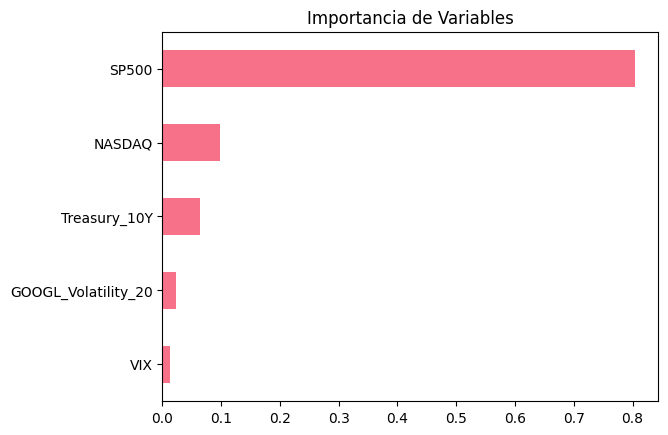

In [20]:
# Importancia de variables
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title='Importancia de Variables')
plt.savefig('feature_importance.png')
plt.show()

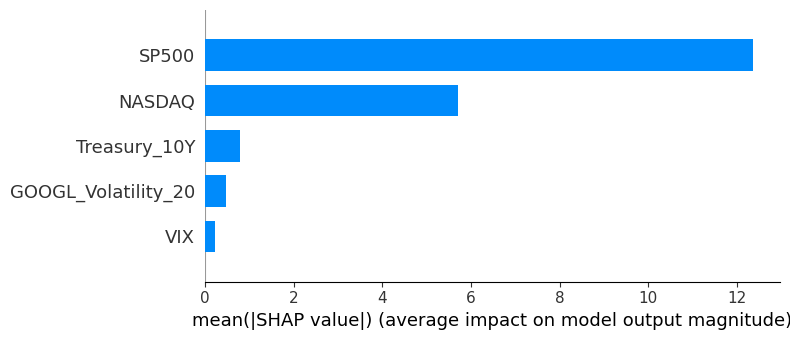

<Figure size 640x480 with 0 Axes>

In [21]:
# SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')
plt.savefig('shap_summary.png')
plt.show()

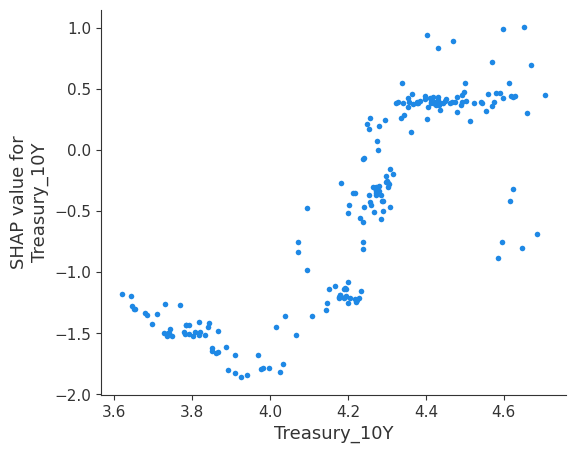

<Figure size 640x480 with 0 Axes>

In [22]:
# Gráfico de dependencia parcial
shap.dependence_plot('Treasury_10Y', shap_values, X_test, interaction_index=None)
plt.savefig('partial_dependence.png')
plt.show()

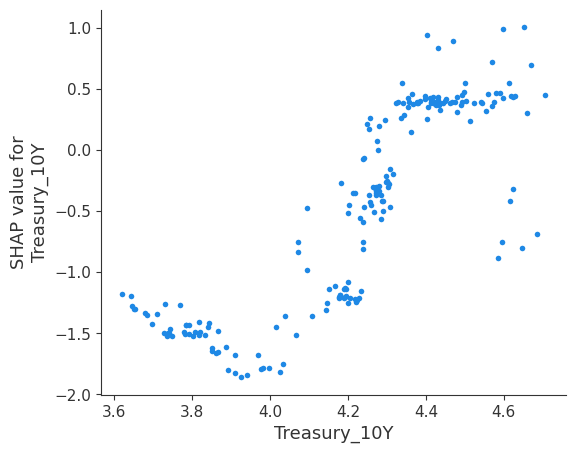

<Figure size 640x480 with 0 Axes>

In [23]:
# Gráfico de dependencia parcial
shap.dependence_plot('Treasury_10Y', shap_values, X_test, interaction_index=None)
plt.savefig('partial_dependence.png')
plt.show()

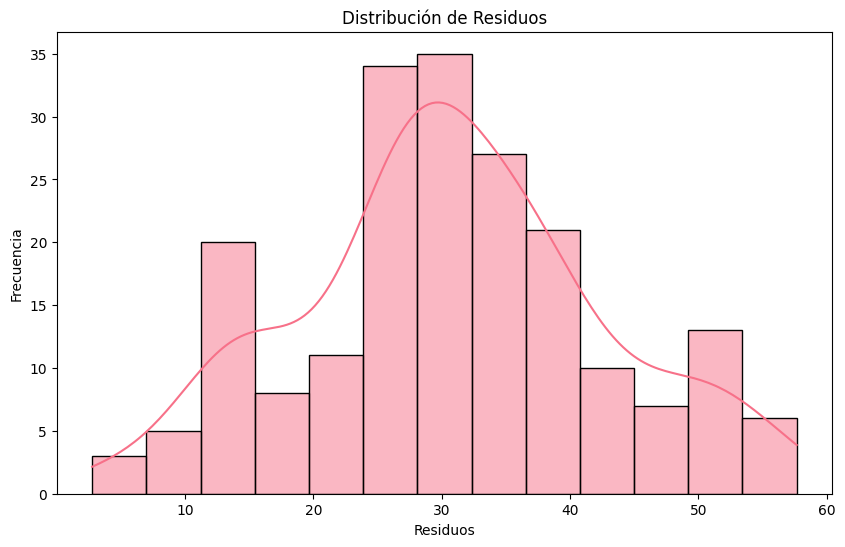

In [24]:
# Análisis de residuos
residuals = y_test - y_pred

# Distribución de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.savefig('residuals_distribution.png')
plt.show()

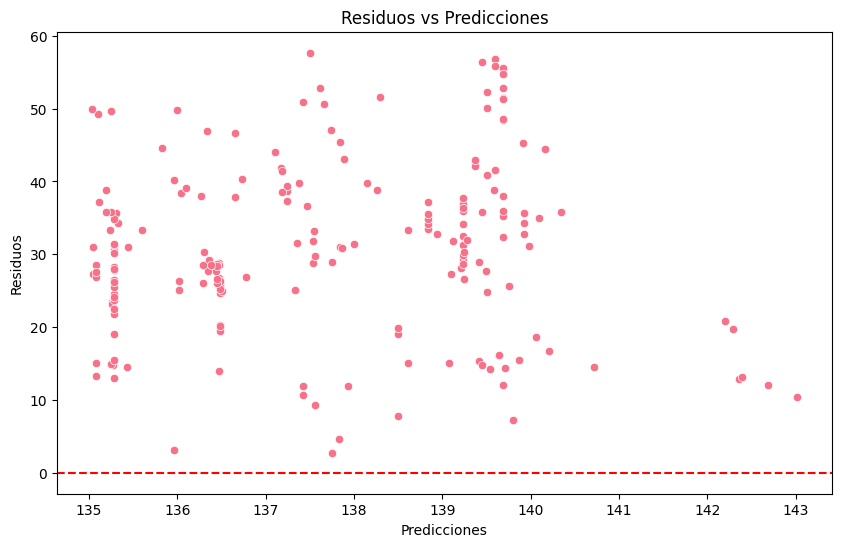

In [25]:
# Residuos vs Predicciones
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.savefig('residuals_vs_predictions.png')
plt.show()

In [26]:
# Pronósticos con valores específicos
example_data = pd.DataFrame({
    'Treasury_10Y': [2.5, 3.0, 3.5],
    'VIX': [20, 25, 30],
    'SP500': [4000, 4100, 4200],
    'NASDAQ': [13000, 13500, 14000],
    'GOOGL_Volatility_20': [3.0, 3.5, 4.0]
})

predictions = model.predict(example_data)
print('Pronósticos para diferentes valores de tasas de interés:')
print(predictions)

Pronósticos para diferentes valores de tasas de interés:
[107.81029938 113.74392982 123.53070206]


In [27]:
# Resumen de hallazgos
print("Resumen de Hallazgos:")
print(f"- Importancia de tasas de interés: {importance['Treasury_10Y']:.2%}")
print(f"- Sensibilidad promedio: {(max(predictions) - min(predictions)) / df['GOOGL_Close'].mean():.2%}")


Resumen de Hallazgos:
- Importancia de tasas de interés: 6.31%
- Sensibilidad promedio: 12.12%


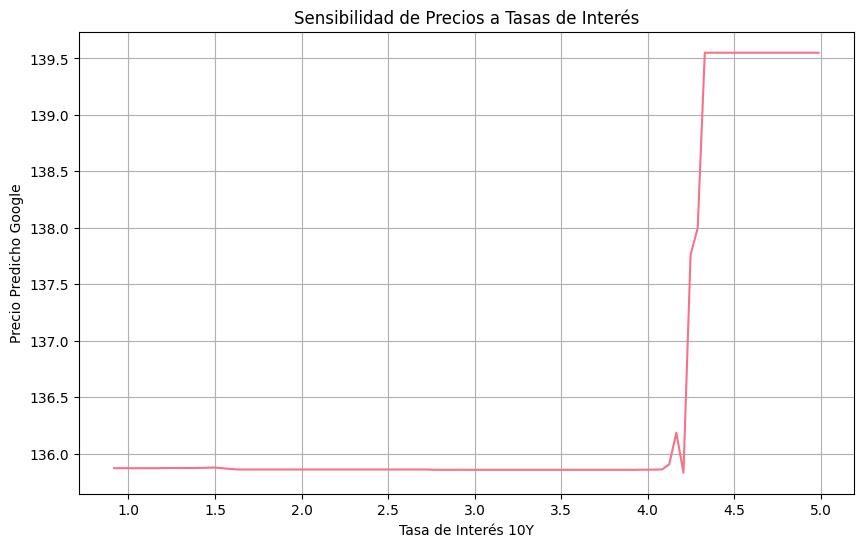

In [28]:
# Análisis de sensibilidad
rates = np.linspace(df['Treasury_10Y'].min(), df['Treasury_10Y'].max(), 100)
predictions = []
for r in rates:
    X_test_scenario = X_test.copy()
    X_test_scenario['Treasury_10Y'] = r
    predictions.append(model.predict(X_test_scenario).mean())

plt.figure(figsize=(10, 6))
plt.plot(rates, predictions)
plt.title('Sensibilidad de Precios a Tasas de Interés')
plt.xlabel('Tasa de Interés 10Y')
plt.ylabel('Precio Predicho Google')
plt.grid(True)
plt.savefig('sensitivity_analysis.png')
plt.show()

In [32]:
# Resumen de hallazgos
print("Resumen de Hallazgos:")
print(f"- Importancia de tasas de interés: {importance['Treasury_10Y']:.2%}")
print(f"- Sensibilidad promedio: {(max(predictions) - min(predictions)) / df['GOOGL_Close'].mean():.2%}")

Resumen de Hallazgos:
- Importancia de tasas de interés: 6.31%
- Sensibilidad promedio: 2.87%


#HIPOTESIS 1

In [46]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 15.4 MB/s eta 0:00:00


In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 13.3 MB/s eta 0:00:00


In [47]:
!pip install shap

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import shap

In [49]:
# Configuración de estilo
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [50]:
# Cargar datos
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'])

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 997 non-null    datetime64[ns]
 1   GOOGL_Close          997 non-null    float64       
 2   AMZN_Close           997 non-null    float64       
 3   Treasury_10Y         997 non-null    float64       
 4   VIX                  997 non-null    float64       
 5   SP500                997 non-null    float64       
 6   NASDAQ               997 non-null    float64       
 7   GOOGL_Return_1d      997 non-null    float64       
 8   AMZN_Return_1d       997 non-null    float64       
 9   GOOGL_Volatility_20  997 non-null    float64       
 10  AMZN_Volatility_20   997 non-null    float64       
 11  Inflacion_T5YIE      997 non-null    float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 93.6 KB


In [52]:
# Crear retornos logarítmicos
df['GOOGL_Return'] = np.log(df['GOOGL_Close'] / df['GOOGL_Close'].shift(1))
df['AMZN_Return'] = np.log(df['AMZN_Close'] / df['AMZN_Close'].shift(1))

In [53]:
df.head()

,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Return_1d,AMZN_Return_1d,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE,GOOGL_Return,AMZN_Return
0,2021-01-04,85.896,159.331,0.917,26.970,3700.650,12698.450,0.008,0.010,3.411,3.842,1.980,NaN,NaN
1,2021-01-05,86.589,160.926,0.955,25.340,3726.860,12818.960,0.008,0.010,3.411,3.842,2.010,0.008,0.010
2,2021-01-06,85.734,156.919,1.042,25.070,3748.140,12740.790,-0.010,-0.025,3.411,3.842,2.040,-0.010,-0.025
3,2021-01-07,88.295,158.108,1.071,22.370,3803.790,13067.480,0.030,0.008,3.411,3.842,2.090,0.029,0.008
4,2021-01-08,89.464,159.135,1.105,21.560,3824.680,13201.980,0.013,0.006,3.411,3.842,2.070,0.013,0.006


In [54]:
# Crear lags de tasas de interés
for lag in [1, 5, 20]:
    df[f'Treasury_10Y_Lag_{lag}'] = df['Treasury_10Y'].shift(lag)

# Eliminar filas con valores nulos
df.dropna(inplace=True)

In [55]:
# Preparación de datos
X = df[['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'GOOGL_Volatility_20']]
y = df['GOOGL_Close']

In [56]:
y

,GOOGL_Close
20,95.499
21,102.454
22,102.193
23,103.945
24,103.730
...,...
992,194.406
993,195.884
994,195.375
995,192.538


In [57]:
# División train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2345, shuffle=False)

In [58]:
# Modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [59]:
# Modelo Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [61]:
# Modelo ARIMA
arima_model = ARIMA(y_train, order=(1, 1, 1))
arima_fit = arima_model.fit()
y_pred_arima = arima_fit.forecast(steps=len(y_test))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

In [63]:
# Modelo GARCH
garch_model = arch_model(y_train, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit()
y_pred_garch = garch_fit.forecast(horizon=len(y_test)).mean.iloc[-1, :]

Iteration:      1,   Func. Count:      6,   Neg. LLF: 186692.71263405296
Iteration:      2,   Func. Count:     13,   Neg. LLF: 3233.0266034013202
Iteration:      3,   Func. Count:     19,   Neg. LLF: 3109.1254821290013
Iteration:      4,   Func. Count:     25,   Neg. LLF: 3105.8237092352724
Iteration:      5,   Func. Count:     31,   Neg. LLF: 3068.601378623558
Iteration:      6,   Func. Count:     36,   Neg. LLF: 3197.308133969143
Iteration:      7,   Func. Count:     42,   Neg. LLF: 3216.4132501594027
Iteration:      8,   Func. Count:     48,   Neg. LLF: 3122.653063698097
Iteration:      9,   Func. Count:     54,   Neg. LLF: 3067.2904327589026
Iteration:     10,   Func. Count:     60,   Neg. LLF: 3066.0469739514047
Iteration:     11,   Func. Count:     65,   Neg. LLF: 3065.9892280983386
Iteration:     12,   Func. Count:     70,   Neg. LLF: 3065.9086392385843
Iteration:     13,   Func. Count:     75,   Neg. LLF: 3065.824879824753
Iteration:     14,   Func. Count:     80,   Neg. LLF: 3

In [64]:
# Modelo Regresión Múltiple
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [65]:
# Evaluación de modelos
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    maep = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame({
        'Modelo': [model_name],
        'MSE': [mse],
        'RMSE': [rmse],
        'MAE': [mae],
        'MAPE': [mape],
        'R²': [r2]
    })

results = pd.concat([
    evaluate_model(y_test, y_pred_rf, 'Random Forest'),
    evaluate_model(y_test, y_pred_gb, 'Gradient Boosting'),
    evaluate_model(y_test, y_pred_arima, 'ARIMA'),
    evaluate_model(y_test, y_pred_garch, 'GARCH'),
    evaluate_model(y_test, y_pred_lr, 'Regresión Múltiple')
])

print(results)

               Modelo      MSE   RMSE    MAE  MAPE      R²
0       Random Forest  986.199 31.404 30.750 0.171  -6.431
0   Gradient Boosting 1042.630 32.290 30.750 0.174  -6.856
0               ARIMA  726.510 26.954 30.750 0.140  -4.474
0               GARCH 2392.260 48.911 30.750 0.278 -17.026
0  Regresión Múltiple  337.544 18.372 30.750 0.091  -1.543


In [66]:
evaluation_df = pd.concat([
    evaluate_model(y_test, y_pred_rf, 'Random Forest'),
    evaluate_model(y_test, y_pred_gb, 'Gradient Boosting')])

In [67]:
print(evaluate_model)

<function evaluate_model at 0x7ceefff73380>


In [68]:
# Prueba de Diebold-Mariano
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller


In [69]:
# Prueba de Ljung-Box para autocorrelación
lb_test = acorr_ljungbox(y_test - y_pred_rf, lags=[10])
print('Prueba de Ljung-Box para Random Forest:')
print(lb_test)

Prueba de Ljung-Box para Random Forest:
    lb_stat  lb_pvalue
10 1177.008      0.000


In [70]:
# Prueba de Dickey-Fuller para estacionariedad
adf_test = adfuller(y_test - y_pred_rf)
print('Prueba de Dickey-Fuller para Random Forest:')
print(adf_test)

Prueba de Dickey-Fuller para Random Forest:
(np.float64(-1.8522276780658449), np.float64(0.3548573594114937), 2, 193, {'1%': np.float64(-3.4646940755442612), '5%': np.float64(-2.8766348847254934), '10%': np.float64(-2.5748163958763994)}, np.float64(919.2373555571188))


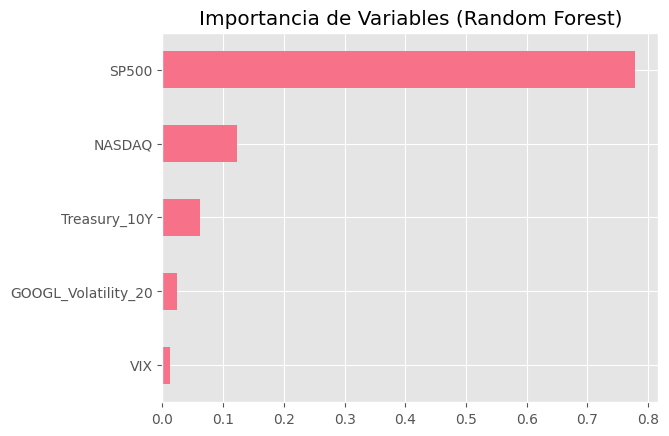

In [71]:
# Visualizaciones
# Importancia de variables en Random Forest
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title='Importancia de Variables (Random Forest)')
plt.savefig('feature_importance_rf.png')
plt.show()

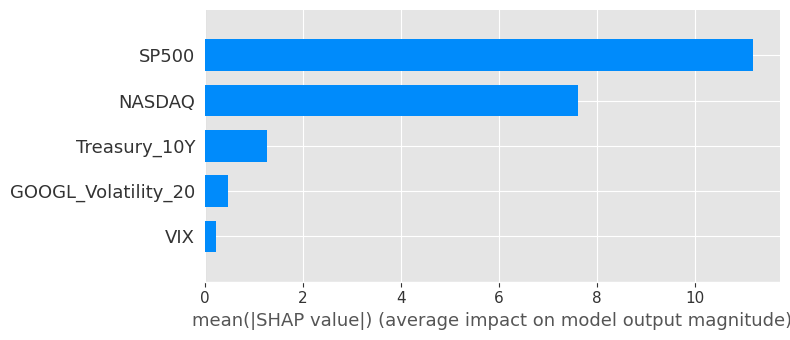

<Figure size 640x480 with 0 Axes>

In [72]:
# SHAP values para Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')
plt.savefig('shap_summary_rf.png')
plt.show()

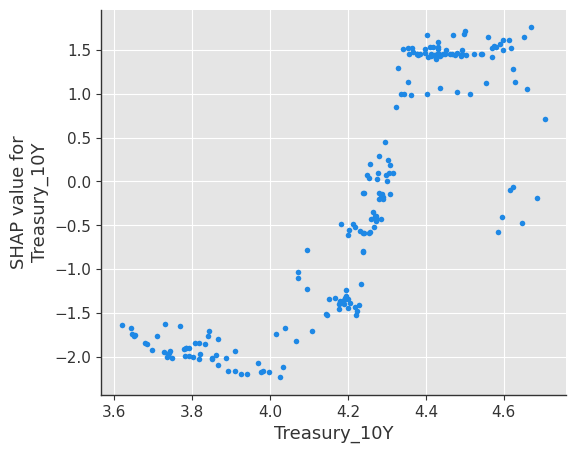

<Figure size 640x480 with 0 Axes>

In [73]:
# Gráfico de dependencia parcial para tasas de interés en Random Forest
shap.dependence_plot('Treasury_10Y', shap_values, X_test, interaction_index=None)
plt.savefig('partial_dependence_rf.png')
plt.show()

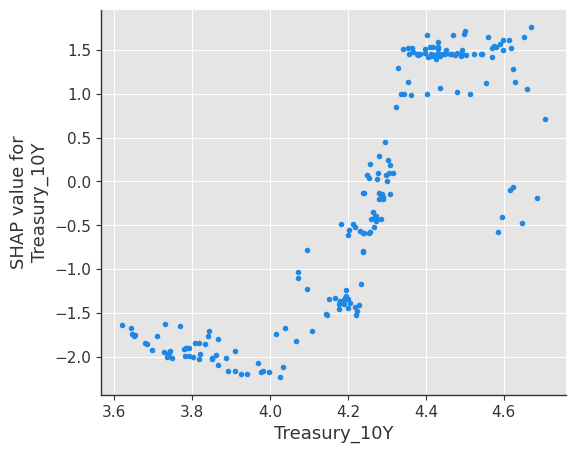

<Figure size 640x480 with 0 Axes>

In [74]:
# Gráfico de dependencia parcial para tasas de interés en Random Forest
shap.dependence_plot('Treasury_10Y', shap_values, X_test, interaction_index=None)
plt.savefig('partial_dependence_rf.png')
plt.show()

In [75]:
# Residuos de Random Forest
residuals_rf = y_test - y_pred_rf

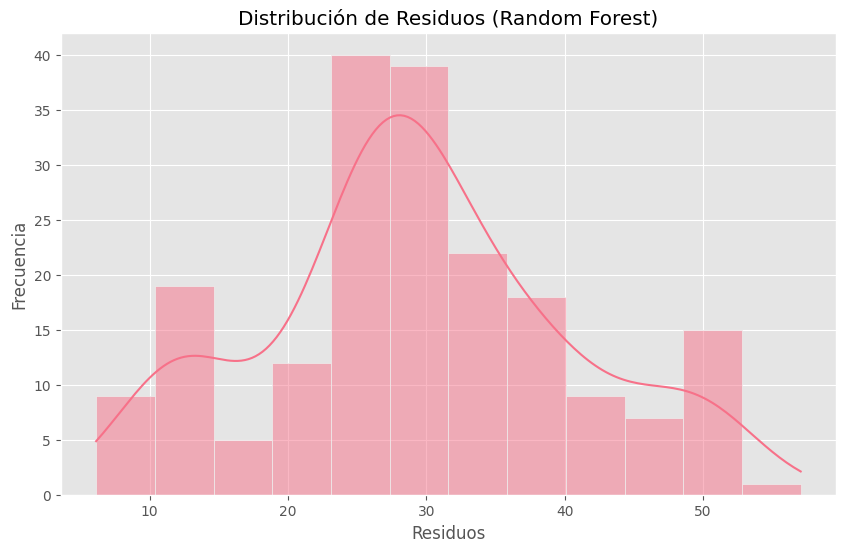

In [76]:
# Distribución de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True)
plt.title('Distribución de Residuos (Random Forest)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.savefig('residuals_distribution_rf.png')
plt.show()

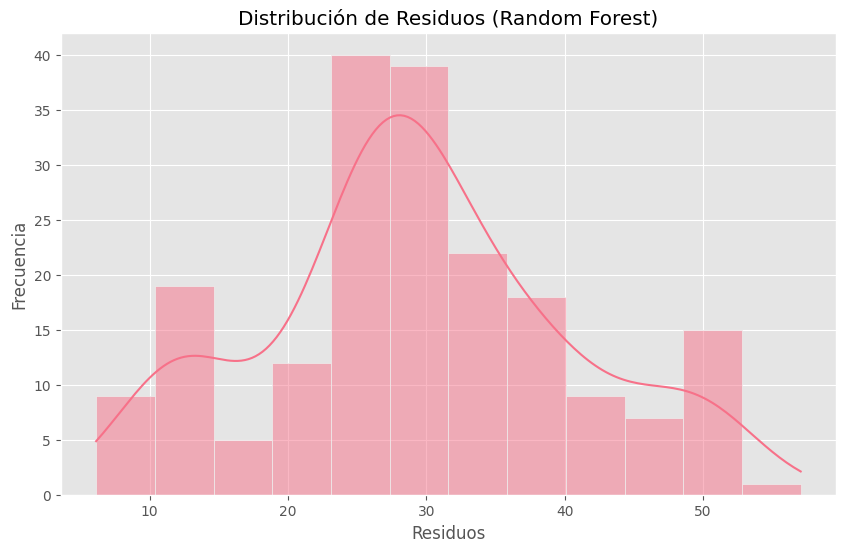

In [77]:
# Distribución de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True)
plt.title('Distribución de Residuos (Random Forest)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.savefig('residuals_distribution_rf.png')
plt.show()

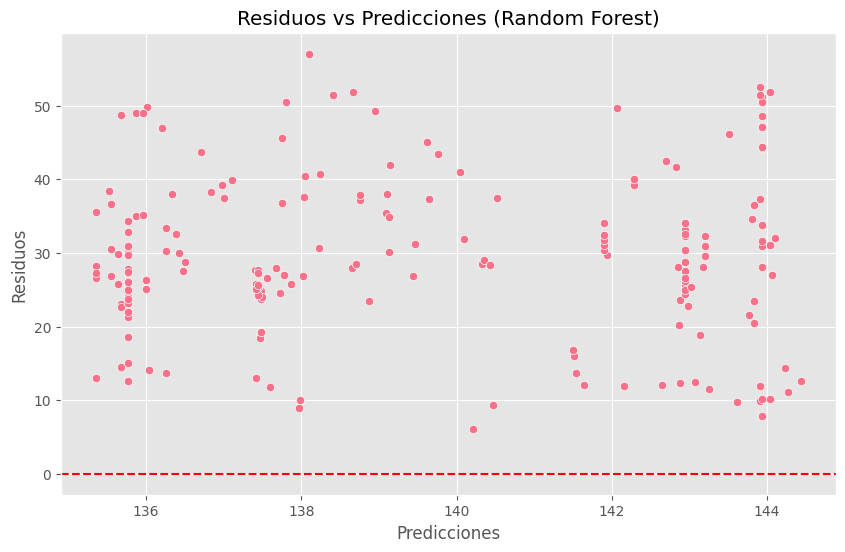

In [78]:
# Residuos vs Predicciones
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Predicciones (Random Forest)')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.savefig('residuals_vs_predictions_rf.png')
plt.show()

In [79]:
# Pronósticos con valores específicos
example_data = pd.DataFrame({
    'Treasury_10Y': [2.5, 3.0, 3.5],
    'VIX': [20, 25, 30],
    'SP500': [4000, 4100, 4200],
    'NASDAQ': [13000, 13500, 14000],
    'GOOGL_Volatility_20': [3.0, 3.5, 4.0]
})

predictions_rf = rf_model.predict(example_data)
predictions_gb = gb_model.predict(example_data)
predictions_lr = lr_model.predict(example_data)

print('Pronósticos para diferentes valores de tasas de interés:')
print('Random Forest:', predictions_rf)
print('Gradient Boosting:', predictions_gb)
print('Regresión Múltiple:', predictions_lr)

Pronósticos para diferentes valores de tasas de interés:
Random Forest: [107.65470322 113.19684097 122.93837784]
Gradient Boosting: [106.05218905 115.76421057 122.69656404]
Regresión Múltiple: [111.4187301  122.85299907 134.28726804]


In [80]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [85]:
# Importaciones necesarias
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import ARIMA as DartsARIMA

# Cargar datos
df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'])

# Verificar y completar fechas faltantes
df.set_index('Date', inplace=True)
df = df.asfreq('B', method='ffill')  # Frecuencia de días de negocios

In [88]:
# Crear la serie de tiempo con frecuencia definida
series = TimeSeries.from_dataframe(df, value_cols='GOOGL_Close', fill_missing_dates=True, freq='B')

# Dividir en train y validation
train, val = series.split_before(pd.Timestamp('2024-01-01'))

# Modelo ARIMA con Darts
darts_arima = DartsARIMA(p=1, d=1, q=1)
darts_arima.fit(train)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(p=1, d=1, q=1, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

In [89]:
# Generar predicciones para 2025
future_predictions = darts_arima.predict(252)  # 252 días de negocios en un año


In [92]:
future_predictions

<TimeSeries (DataArray) (Date: 252, component: 1, sample: 1)> Size: 2kB
array([[[138.9526903 ]],

       [[138.89068551]],

       [[138.8377583 ]],

       [[138.79257971]],

       [[138.75401532]],

       [[138.72109682]],

       [[138.69299763]],

       [[138.6690122 ]],

       [[138.64853826]],

       [[138.63106174]],

...

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]],

       [[138.52916424]]])
Coordinates:
  * Date       (Date) datetime64[ns] 2kB 2024-01-01 2024-01-02 ... 2024-12-17
  * component  (component) object 8B 'GOOGL_Close'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

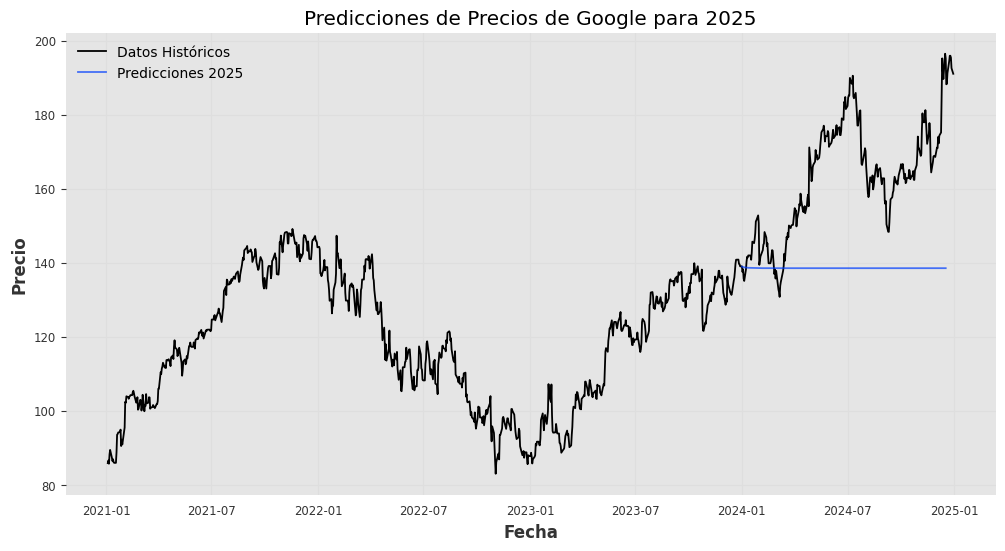

In [93]:
# Visualización de predicciones futuras
plt.figure(figsize=(12, 6))
plt.plot(series.time_index, series.values(), label='Datos Históricos')
plt.plot(future_predictions.time_index, future_predictions.values(), label='Predicciones 2025', alpha=0.7)
plt.title('Predicciones de Precios de Google para 2025')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.savefig('predictions_2025.png')
plt.show()